<a href="https://colab.research.google.com/github/todd-jang/AIFFEL_quest_rs/blob/main/GoingDeeper/08_KoChatGPT/KoChatGPTv6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KoChatGPT 2026 Colab Research v4

정제/Best-of-N/한글 tokenizer 수정을 통합한 버전입니다.


In [1]:
# Colab/Notebook 환경 점검
import sys, os, json, random, re, math, statistics, warnings
import torch, transformers

print("Python      :", sys.version.split()[0])
print("PyTorch     :", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA        :", torch.version.cuda)
print("GPU         :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# 현재 노트북에서는 ColossalAI/TRL을 사용하지 않습니다.
assert tuple(map(int, transformers.__version__.split(".")[:2])) >= (4, 30),     "transformers 버전이 너무 낮습니다."

SEED = 230319
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ROOT = "/content/KoChatGPT"
DATA_DIR = f"{ROOT}/data_kochatgpt"
SFT_PATH = f"{DATA_DIR}/kochatgpt_1_SFT.jsonl"
RM_PATH = f"{DATA_DIR}/kochatgpt_2_RM.jsonl"
CLEANED_SFT_PATH = "/content/kochatgpt_1_SFT_cleaned.jsonl"

print("SFT:", SFT_PATH)
print("RM :", RM_PATH)


Python      : 3.13.15
PyTorch     : 2.11.0+cu128
Transformers: 5.16.1
CUDA        : 12.8
GPU         : NVIDIA RTX PRO 6000 Blackwell Server Edition
SFT: /content/KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl
RM : /content/KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl


In [8]:
# 데이터/저장소 준비
import os, subprocess, shutil

if not os.path.exists(ROOT):
    subprocess.run(["git", "clone", "https://github.com/airobotlab/KoChatGPT", ROOT], check=True)

assert os.path.exists(SFT_PATH), f"SFT 데이터가 없습니다: {SFT_PATH}"
assert os.path.exists(RM_PATH), f"RM 데이터가 없습니다: {RM_PATH}"
print("데이터 준비 완료")


데이터 준비 완료


## 2-1. 데이터 파일 재다운로드

이전 단계에서 `.jsonl` 데이터 파일(`kochatgpt_1_SFT.jsonl`, `kochatgpt_2_RM.jsonl`, `kochatgpt_3_PPO.jsonl`)을 로드하는 데 실패했습니다. 이는 파일이 손상되었거나 올바른 내용이 포함되어 있지 않기 때문일 수 있습니다. 이 문제를 해결하기 위해 기존 `data_kochatgpt` 디렉토리를 제거하고 GitHub에서 올바른 데이터 파일을 다시 다운로드하겠습니다.

In [3]:
import os
import shutil

# 기존 data_kochatgpt 디렉토리 제거
if os.path.exists(DATA_DIR):
    print(f"Removing existing data directory: {DATA_DIR}")
    shutil.rmtree(DATA_DIR)
    os.makedirs(DATA_DIR, exist_ok=True)

# data_kochatgpt 디렉토리가 없으면 생성
else:
    print(f"Creating data directory: {DATA_DIR}")
    os.makedirs(DATA_DIR, exist_ok=True)

# 필요한 데이터 파일 다운로드
print("Downloading SFT data...")
!wget -O "{SFT_PATH}" https://raw.githubusercontent.com/airobotlab/KoChatGPT/main/data_kochatgpt/kochatgpt_1_SFT.jsonl

print("Downloading RM data...")
!wget -O "{RM_PATH}" https://raw.githubusercontent.com/airobotlab/KoChatGPT/main/data_kochatgpt/kochatgpt_2_RM.jsonl

print("Downloading PPO data...")
!wget -O "{PPO_PATH}" https://raw.githubusercontent.com/airobotlab/KoChatGPT/main/data_kochatgpt/kochatgpt_3_PPO.jsonl

print("데이터 파일 다운로드 완료.")

Removing existing data directory: /content/KoChatGPT/data_kochatgpt
--2026-09-18 01:21:14--  https://raw.githubusercontent.com/airobotlab/KoChatGPT/main/data_kochatgpt/kochatgpt_1_SFT.jsonl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5715720 (5.5M) [application/octet-stream]
Saving to: ‘/content/KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl’

/content/KoChatGPT/ 100%[===================>]   5.45M  --.-KB/s    in 0.05s   

2026-09-18 01:21:15 (102 MB/s) - ‘/content/KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl’ saved [5715720/5715720]

--2026-09-18 01:21:15--  https://raw.githubusercontent.com/airobotlab/KoChatGPT/main/data_kochatgpt/kochatgpt_2_RM.jsonl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133,

In [4]:
import os

# 0. Configuration
RUN_MODE = "full"       # "smoke" 또는 "full"
SEED = 42

# Correctly derive DATA_DIR from ROOT to ensure files are found in the cloned repository
DATA_DIR = os.path.join(ROOT, "data_kochatgpt")
SFT_PATH = os.path.join(DATA_DIR, "kochatgpt_1_SFT.jsonl")
RM_PATH  = os.path.join(DATA_DIR, "kochatgpt_2_RM.jsonl")   # 실제 repo 기준 파일명 (kochatgpt_1_RM 아님)
PPO_PATH = os.path.join(DATA_DIR, "kochatgpt_3_PPO.jsonl")  # 실제 repo 기준 파일명 (kochatgpt_1_PPO 아님)

OUT_DIR = "/content/kochatgpt_outputs"

KOGPT2_MODEL = "skt/kogpt2-base-v2"
TRINITY_MODEL = "skt/ko-gpt-trinity-1.2B-v0.5"

# skt/kogpt2-base-v2 공식 사용법의 Instruction/Response 템플릿.
# SFT 학습과 생성(inference) 양쪽에서 반드시 동일하게 사용해야 합니다.
PROMPT_TEMPLATE = "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"

MAX_TRAIN_SAMPLES = None if RUN_MODE == "full" else 500
MAX_EVAL_SAMPLES = 200 if RUN_MODE == "full" else 30
MAX_LENGTH = 512
NUM_EPOCHS_KOGPT2 = 2
NUM_EPOCHS_TRINITY = 2

RUN_KOGPT2_SFT = True
RUN_RM = True
RUN_PPO = True
RUN_TRINITY_SFT = True
RUN_TRINITY_LORA = True
RUN_DECODING_SEARCH = True
RM_MAX_SAMPLES = None if RUN_MODE == "full" else 300

os.makedirs(OUT_DIR, exist_ok=True)


In [5]:
# 1. Install / environment
!pip -q install -U transformers datasets accelerate peft trl evaluate rouge-score sacrebleu sentencepiece pandas matplotlib seaborn scikit-learn

import os, re, json, time, math, gc, random, html, unicodedata, inspect
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import transformers, datasets, peft, accelerate, trl

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("peft:", peft.__version__)
print("trl:", trl.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory/1024**3, 2))


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 132.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 112.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 138.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 148.1 MB/s eta 0:00:00
  

### 한글 폰트 설정

Colab 기본 matplotlib에는 한글 폰트가 없어 그래프 라벨이 네모(□)로 깨져 보입니다.
아래 셀을 세션당 한 번만 실행하면 이후 모든 그래프에 적용됩니다.


In [6]:
# 한글 폰트 설치 및 적용 (세션당 1회)
!apt-get -qq install -y fonts-nanum > /dev/null
import matplotlib
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False


## 2. 데이터 로드 및 품질 Audit

`data_kochatgpt` 폴더의 세 파일을 각각 로드하고 Audit합니다.

- `kochatgpt_1_SFT.jsonl`: SFT용 prompt/completion (원본, 비정제)
- `kochatgpt_2_RM.jsonl`: RM용 prompt + completion_0/1/2 + ranking (human ranking)
- `kochatgpt_3_PPO.jsonl`: PPO용 prompt only

세 말뭉치의 도메인/문체/길이분포/완성도를 각각 확인한 뒤,
그 결과를 바탕으로 SFT 데이터를 정제·증량하고, 정제 전/후 성능을 직접 비교합니다.


In [9]:
import os
import shutil

# 이전 다운로드 셀에서 잘못된 이름으로 저장된 PPO 파일을 올바른 경로로 이동합니다.
misnamed_file = "/content/{PPO_PATH}"
if os.path.exists(misnamed_file):
    shutil.move(misnamed_file, PPO_PATH)
elif os.path.exists("{PPO_PATH}"):
    shutil.move("{PPO_PATH}", PPO_PATH)

# 2-1. Load JSONL (SFT / RM / PPO)
for _p in [SFT_PATH, RM_PATH, PPO_PATH]:
    assert os.path.exists(_p), f"파일이 없습니다: {_p}"

def load_jsonl(path):
    # 기존 load_jsonl 함수는 한 라인에 하나의 JSON 객체를 기대했으나,
    # 파일이 JSON 배열로 구성되어 있어 전체 파일을 읽고 파싱하도록 수정합니다.
    with open(path, "r", encoding="utf-8") as f:
        content = f.read()
    try:
        data = json.loads(content)
        return pd.DataFrame(data), []
    except Exception as e:
        # 단일 JSON 배열로 파싱 실패 시, 기존 JSON Lines 방식으로 시도 (혹시 모를 다른 형식 대비)
        rows = []; bad = []
        for i, line in enumerate(content.splitlines()):
            line = line.strip()
            if not line: continue
            try:
                rows.append(json.loads(line))
            except Exception as e_line:
                bad.append((i, str(e_line)))
        return pd.DataFrame(rows), bad

df, bad_sft = load_jsonl(SFT_PATH)
rm_raw, bad_rm = load_jsonl(RM_PATH)
ppo_raw, bad_ppo = load_jsonl(PPO_PATH)

print("[SFT] shape:", df.shape, "| bad lines:", len(bad_sft), "| cols:", df.columns.tolist())
print("[RM]  shape:", rm_raw.shape, "| bad lines:", len(bad_rm), "| cols:", rm_raw.columns.tolist())
print("[PPO] shape:", ppo_raw.shape, "| bad lines:", len(bad_ppo), "| cols:", ppo_raw.columns.tolist())
display(df.head(3)); display(rm_raw.head(3)); display(ppo_raw.head(3))

[SFT] shape: (12000, 3) | bad lines: 0 | cols: ['prompt', 'completion', 'tokens']
[RM]  shape: (10220, 5) | bad lines: 0 | cols: ['prompt', 'completion_0', 'completion_1', 'completion_2', 'ranking']
[PPO] shape: (12000, 1) | bad lines: 0 | cols: ['prompt']


,prompt,completion,tokens
0,불고기용 고기 한우에요?,"'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하...",193
1,쓰던 앱이 유료로 전환됐어,"'어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 ...",288
2,여친이랑 다툼,'저는 인공지능이기 때문에 여친과의 다툼에 대해서는 조언을 드릴 수는 없습니다. 하...,153


,prompt,completion_0,completion_1,completion_2,ranking
0,"번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독...",Allow me to answer your question. I know that ...,번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.,라이언에게 말했다.,"[2, 1, 0]"
1,개포주공아파트는 몇 단지로 이루어져 있나?,개포주공아파트는 다섯 단지로 이루어져 있습니다.,이날 목송에서 구글상위노,개포주공아파트는 총 27개 단지로 이루어져 있습니다.,"[2, 0, 1]"
2,김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?,The diameter of the Metallic domain is bigger ...,"이 질문은 조금 불분명합니다. 김영삼 대통령이 후보 시절에 어떤 발언을 했고, 누가...",김영삼의 후보 시절에 지역표심을 겨냥한 발언은 대통령 당선 전까지 대한민국 정부가 ...,"[1, 2, 0]"


,prompt
0,"번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독..."
1,개포주공아파트는 몇 단지로 이루어져 있나?
2,김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?


In [10]:
# 2-2. Structural audit
for col in ["prompt","completion"]:
    df[col]=df[col].fillna("").astype(str)

def flags(s):
    return {
        "chars": len(s),
        "words": len(s.split()),
        "html": bool(re.search(r"<[^>]+>",s)),
        "url": bool(re.search(r"https?://|www\\.",s,re.I)),
        "email": bool(re.search(r"\\b[\\w.+-]+@[\\w.-]+\\.\\w+\\b",s)),
        "repeat_punct": bool(re.search(r"([!?.,])\\1{2,}",s)),
        "repeat_char": bool(re.search(r"(.)\\1{5,}",s)),
    }

for col in ["prompt","completion"]:
    t=df[col].map(flags).apply(pd.Series)
    t.columns=[f"{col}_{c}" for c in t.columns]
    df=pd.concat([df,t],axis=1)

prompt_counts=df.groupby("prompt").size()
summary=pd.Series({
    "rows":len(df),
    "empty_prompt":(df.prompt.str.strip()=="").sum(),
    "empty_completion":(df.completion.str.strip()=="").sum(),
    "pair_duplicate_rows":df.duplicated(["prompt","completion"],keep=False).sum(),
    "duplicate_prompt_rows":df.duplicated("prompt",keep=False).sum(),
    "unique_prompts":df.prompt.nunique(),
    "prompts_with_multiple_completions":(prompt_counts>1).sum(),
    "html_rows":(df.prompt_html|df.completion_html).sum(),
    "url_rows":(df.prompt_url|df.completion_url).sum(),
    "email_rows":(df.prompt_email|df.completion_email).sum(),
    "repeat_punctuation_rows":(df.prompt_repeat_punct|df.completion_repeat_punct).sum(),
    "repeat_character_rows":(df.prompt_repeat_char|df.completion_repeat_char).sum(),
})
display(summary.to_frame("count"))


,count
rows,12000
empty_prompt,3
empty_completion,0
pair_duplicate_rows,0
duplicate_prompt_rows,99
unique_prompts,11946
prompts_with_multiple_completions,45
html_rows,18
url_rows,6
email_rows,0


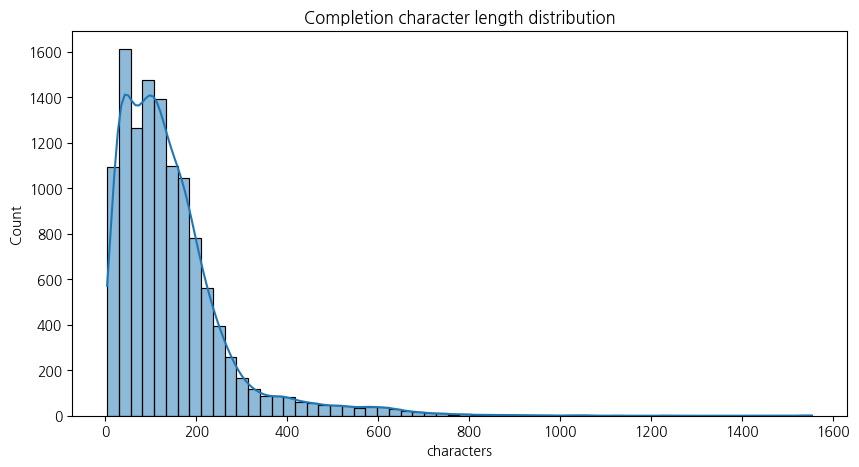

,chars
0.50,118.0
0.90,268.0
0.95,382.0
0.99,628.0
1.00,1553.0


In [11]:
# 2-3. Length EDA
fig,ax=plt.subplots(figsize=(10,5))
sns.histplot(df.completion_chars,bins=60,kde=True,ax=ax)
ax.set_title("Completion character length distribution")
ax.set_xlabel("characters")
plt.show()
display(df.completion_chars.quantile([.5,.9,.95,.99,1]).to_frame("chars"))


In [12]:
# 2-4. Multi-completion groups: preserve for RM candidates
multi_prompts=prompt_counts[prompt_counts>1].index
multi=df[df.prompt.isin(multi_prompts)][["prompt","completion"]].copy()
print("rows in multi-completion groups:",len(multi))
display(multi.head(20))
multi.to_json(os.path.join(OUT_DIR,"multi_completion_candidates.jsonl"),
              orient="records",lines=True,force_ascii=False)


rows in multi-completion groups: 99


,prompt,completion
110,지금 배달되나요?,"'죄송하지만, 저는 배달 관련 정보를 알 수 없습니다. 배달 서비스를 이용하신 업체..."
265,여기는 몇 시부터 몇 시까지 문 열어요?,"""I'm sorry, I cannot answer this question as I..."
507,어떤 게 잘 나가요?,"'제가 알고 있는 정보에서, 이제는 온라인 쇼핑, 스트리밍 서비스, 비대면 서비스들..."
657,비 오는데?,"'저는 인공지능 챗봇으로 비가 오는지 알 수 없습니다. 하지만, 대부분의 기상 예보..."
782,여기 체인점인가요?,'죄송합니다. 저는 AI 어시스턴트이기 때문에 현재 위치나 주변 상황을 파악할 수 ...
1146,몇 시에 문 열어요?,"'제가 가지고 있는 정보에 따르면, 어떤 문에 대해서 물어보는 것인지 명확하지 않습..."
1201,이거는 얼마예요?,'저는 가격을 알 수 없습니다. 구체적인 물건이나 상황을 제시해주시면 답변을 드릴 ...
1276,현금영수증 되나요?,'저는 AI 어시스턴트이기 때문에 현금영수증을 발급할 수는 없습니다. 현금영수증 발...
1571,얼마에요?,'물건이나 서비스의 가격을 묻는 한국어 표현입니다. 하지만 구체적인 상황과 물건 종...
1612,비 오는데?,"'저는 비가 내리는지 아닌지 알 수 없습니다. 저는 인공지능 챗봇이며, 현재 위치와..."


## 3. 의미 품질 Audit (REMOVE / REVIEW / KEEP)

단순 통계(길이, HTML 존재 여부)를 넘어, 실제 발견된 노이즈 패턴을 규칙화합니다.

- **REMOVE** (명확한 결함, 자동 제거): 빈값, prompt==completion, 완전 중복,
  URL/HTML, 개인정보(전화번호/이메일)
- **REVIEW** (애매함, 사람 판단 필요 — 자동 제거하지 않고 보존):
  지나치게 짧음/김, 반복 단어/문장, 언어 혼입(영어 위주), AI 회피성 답변
  (`"저는 인공지능..."`류)

REVIEW까지 무조건 제거하면 정상적인 한국어 응답이 손실될 수 있으므로,
**실제 정제 단계에서는 REMOVE 사유가 있는 행만 제거**합니다.


In [13]:
# 3-1. REMOVE / REVIEW / KEEP audit
REFUSAL_RE = re.compile(
    r"AI\s*언어모델|저는\s*인공지능|as an ai language model|i am an ai|i'm an ai",
    re.IGNORECASE,
)
PHONE_RE = re.compile(r"(01[016789]-?\d{3,4}-?\d{4})|(\d{2,3}-\d{3,4}-\d{4})")
EMAIL_RE = re.compile(r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
HTML_RE = re.compile(r"<[a-zA-Z/][^>]{0,60}>")
REPEAT_WORD_RE = re.compile(r"(\S+)(\s+\1){2,}")

def kor_lat_ratio(s: str) -> float:
    kor = len(re.findall(r"[가-힣]", s))
    lat = len(re.findall(r"[a-zA-Z]", s))
    total = kor + lat
    return kor / total if total else 1.0

def split_sentences(s: str):
    return [p.strip() for p in re.split(r"(?<=[.!?])\s+|\n+", s) if p.strip()]

def has_repeated_sentence(s: str) -> bool:
    sents = split_sentences(s)
    return len(sents) > 1 and len(sents) != len(set(sents))

def strip_leading_quote(s: str) -> str:
    s = s.strip()
    while s and s[0] in "'\"":
        s = s[1:]
    return s.strip()

def audit_completion(prompt: str, completion: str):
    remove, review = [], []
    p, c = prompt.strip(), completion.strip()
    if not p or not c:
        remove.append("empty")
    if p == c:
        remove.append("prompt=completion")
    if URL_RE.search(c) or HTML_RE.search(c):
        remove.append("url_html")
    if PHONE_RE.search(c) or EMAIL_RE.search(c):
        remove.append("pii")
    if len(c) < 8:
        review.append("too_short")
    if len(c) > 800:
        review.append("too_long")
    if REPEAT_WORD_RE.search(c):
        review.append("repeated_word")
    if has_repeated_sentence(c):
        review.append("repeated_sentence")
    if kor_lat_ratio(c) < 0.30:
        review.append("english_dominant")
    if REFUSAL_RE.search(c):
        review.append("ai_refusal")
    return remove, review

def audit_sft(data_df):
    seen = set()
    rows = []
    for _, d in data_df.iterrows():
        p, c = d["prompt"], d["completion"]
        rm, rv = audit_completion(p, c)
        key = (p.strip(), c.strip())
        if key in seen:
            rm.append("duplicate")
        seen.add(key)
        label = "REMOVE" if rm else ("REVIEW" if rv else "KEEP")
        rows.append({"prompt": p, "completion": c, "label": label, "reasons": ";".join(rm + rv)})
    return pd.DataFrame(rows)

audit_df = audit_sft(df)
print("SFT Audit 결과:")
print(audit_df.label.value_counts())

# 리딩 quote 아티팩트는 REMOVE/REVIEW 판정과 별개로 별도 집계 (정제 단계에서 처리)
leading_quote_ratio = df.completion.map(lambda x: str(x).strip().startswith(("'", '"'))).mean()
print(f"completion 앞에 따옴표가 붙은 비율: {leading_quote_ratio:.1%}")

display(audit_df[audit_df.label != "KEEP"].head(20))
audit_df.to_csv(os.path.join(OUT_DIR, "sft_audit.csv"), index=False, encoding="utf-8-sig")


SFT Audit 결과:
label
KEEP      10238
REVIEW     1752
REMOVE       10
Name: count, dtype: int64
completion 앞에 따옴표가 붙은 비율: 99.8%


,prompt,completion,label,reasons
0,불고기용 고기 한우에요?,"'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하...",REVIEW,ai_refusal
2,여친이랑 다툼,'저는 인공지능이기 때문에 여친과의 다툼에 대해서는 조언을 드릴 수는 없습니다. 하...,REVIEW,ai_refusal
5,입냄새 안나나?,'컴퓨터 앞에서 일하면서 입을 위해 물이나 향초를 끊임없이 찾는 이유가 여기 있군요...,REVIEW,ai_refusal
10,"미스터 허드슨 & 더 라이브러리가 서포팅 밴드로 참여했으며, 아일랜드 더블린 및 유...","'""Canyon Tour"" 입니다.",REVIEW,english_dominant
17,2000년 5월 허위사실유포죄를 위헌판정한 나라는?,'한국입니다.,REVIEW,too_short
25,목 마르다.,"'> ""I am thirsty."" (English) \n\n> ""Je suis as...",REVIEW,english_dominant
34,치홀트는 뉴타이포그래피가 어떤 형태를 해야한다고 주장했어,'.\n\n좋은 질문입니다. 저는 인공지능 언어모델로써 치홀트의 발언을 인지하고 응...,REVIEW,ai_refusal
50,동거 8년 환승이별.,"'8 years of living together, transfer separation.",REVIEW,english_dominant
52,이게 본인이 아니고 다른 사람이 갈 때 한 뭐 갈 때 준비 서류지요,'저는 인공지능 챗봇입니다. 본인이 아닌 다른 사람이 갈 때 준비해야 할 서류는 그...,REVIEW,ai_refusal
58,잘참다가 페북을 봐버렸네,'제가 알기로 AI 언어모델은 인터넷 상에서 아무 문제도 없는 자연스러운 문장들을 ...,REVIEW,ai_refusal


### 3.1 RM 말뭉치 Audit (`kochatgpt_2_RM.jsonl`)

RM 데이터는 `completion_0/1/2` + `ranking`으로 구성됩니다.

`ranking`의 의미: `ranking[k]` = 랭크 `k`(0이 최상위)에 해당하는 completion의 인덱스.
예를 들어 `ranking=[1,2,0]`이면 `completion_1`이 최상위, `completion_2`가 중간,
`completion_0`이 최하위입니다. 이 스키마가 실제로 유효한 permutation인지,
그리고 RM 라벨이 단순히 "길이가 길수록 좋은 점수"로 편향되어 있지 않은지 확인합니다.


In [14]:
# 3-2. RM corpus structural audit
for c in ["prompt", "completion_0", "completion_1", "completion_2"]:
    rm_raw[c] = rm_raw[c].fillna("").astype(str)

def is_valid_ranking(r):
    return isinstance(r, list) and sorted(r) == [0, 1, 2]

rm_raw["ranking_valid"] = rm_raw["ranking"].map(is_valid_ranking)
print("RM rows:", len(rm_raw))
print("invalid ranking rows:", int((~rm_raw.ranking_valid).sum()))
print("duplicate prompt rows:", int(rm_raw.duplicated("prompt", keep=False).sum()))

same_pairs = ((rm_raw.completion_0 == rm_raw.completion_1) |
              (rm_raw.completion_1 == rm_raw.completion_2) |
              (rm_raw.completion_0 == rm_raw.completion_2)).sum()
print("완전히 동일한 completion 쌍을 포함한 행:", int(same_pairs))

def rank_position(row, idx):
    return row["ranking"].index(idx)

_rows = []
for _, r in rm_raw[rm_raw.ranking_valid].iterrows():
    for idx in [0, 1, 2]:
        _rows.append({"rank": rank_position(r, idx), "chars": len(r[f"completion_{idx}"])})
rank_len_df = pd.DataFrame(_rows)
print("랭크별 completion 길이 통계 (0=최상위):")
display(rank_len_df.groupby("rank").chars.describe())


RM rows: 10220
invalid ranking rows: 0
duplicate prompt rows: 71
완전히 동일한 completion 쌍을 포함한 행: 6
랭크별 completion 길이 통계 (0=최상위):


,count,mean,std,min,25%,50%,75%,max
rank,,,,,,,,
0,10220.0,143.142857,124.012901,3.0,61.0,116.0,183.25,1552.0
1,10220.0,86.387280,80.489576,0.0,32.0,69.0,137.00,2321.0
2,10220.0,120.774168,146.197439,0.0,43.0,117.0,136.00,3694.0


### 3.2 세 말뭉치 길이/도메인 비교

SFT prompt, RM completion(0/1/2 합산), PPO prompt의 길이 분포와
prompt 중복도, SFT-PPO 간 도메인 겹침을 확인합니다.


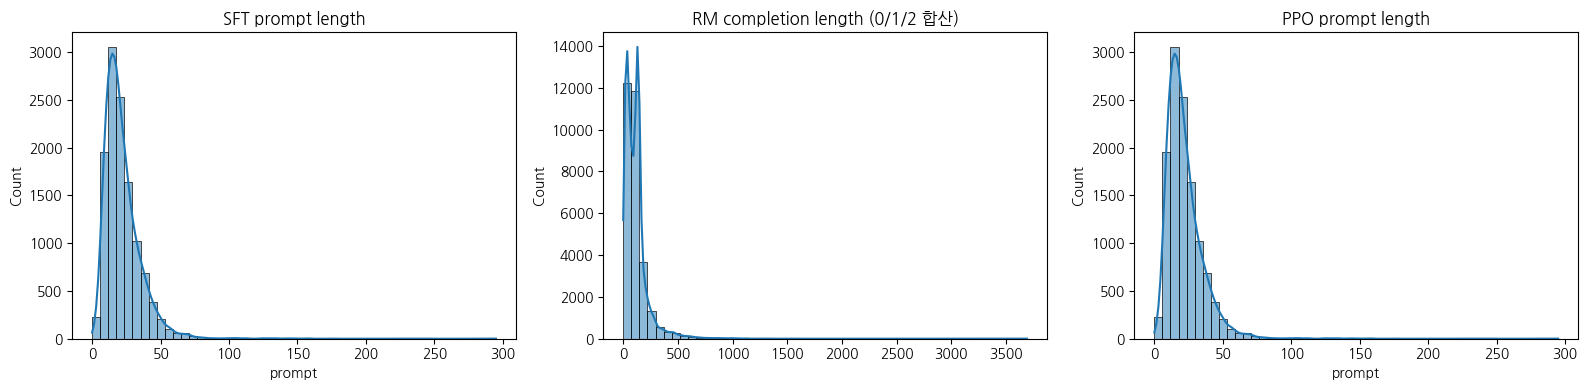

SFT unique prompts: 11946 / rows: 12000
RM  unique prompts: 10181 / rows: 10220
PPO unique prompts: 11946 / rows: 12000
SFT ∩ PPO prompt overlap: 11946


In [15]:
# 3-3. Length distribution across corpora
rm_lengths = pd.concat([rm_raw.completion_0, rm_raw.completion_1, rm_raw.completion_2]).str.len()
ppo_raw["prompt"] = ppo_raw["prompt"].fillna("").astype(str)
ppo_lengths = ppo_raw.prompt.str.len()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df.prompt.str.len(), bins=50, kde=True, ax=axes[0]); axes[0].set_title("SFT prompt length")
sns.histplot(rm_lengths, bins=50, kde=True, ax=axes[1]); axes[1].set_title("RM completion length (0/1/2 합산)")
sns.histplot(ppo_lengths, bins=50, kde=True, ax=axes[2]); axes[2].set_title("PPO prompt length")
plt.tight_layout(); plt.show()

print("SFT unique prompts:", df.prompt.nunique(), "/ rows:", len(df))
print("RM  unique prompts:", rm_raw.prompt.nunique(), "/ rows:", len(rm_raw))
print("PPO unique prompts:", ppo_raw.prompt.nunique(), "/ rows:", len(ppo_raw))
print("SFT ∩ PPO prompt overlap:", len(set(df.prompt) & set(ppo_raw.prompt)))


### 3.3 문장 완성도 및 문체(formal ending) 비교

각 말뭉치의 텍스트가 문장부호/종결어미로 제대로 끝나는지(완성도),
그리고 격식체(-습니다/-요) 비율(문체)을 비교합니다.


In [16]:
# 3-4. 완성도 / 문체 audit
def ends_properly(t):
    t = str(t).strip()
    return bool(re.search(r"[.?!다요까]$", t))

def formal_ending_ratio(texts):
    t = texts.astype(str)
    return t.map(lambda x: bool(re.search(r"(습니다|입니다|해요|세요)\s*[.!?]?$", x.strip()))).mean()

corpus_summary = pd.DataFrame({
    "corpus": ["SFT completion", "RM completion_0", "RM completion_1", "RM completion_2", "PPO prompt"],
    "n": [len(df), len(rm_raw), len(rm_raw), len(rm_raw), len(ppo_raw)],
    "avg_chars": [
        df.completion.str.len().mean(), rm_raw.completion_0.str.len().mean(),
        rm_raw.completion_1.str.len().mean(), rm_raw.completion_2.str.len().mean(),
        ppo_raw.prompt.str.len().mean()
    ],
    "ends_properly_ratio": [
        df.completion.map(ends_properly).mean(), rm_raw.completion_0.map(ends_properly).mean(),
        rm_raw.completion_1.map(ends_properly).mean(), rm_raw.completion_2.map(ends_properly).mean(),
        ppo_raw.prompt.map(ends_properly).mean()
    ],
    "formal_ending_ratio": [
        formal_ending_ratio(df.completion), formal_ending_ratio(rm_raw.completion_0),
        formal_ending_ratio(rm_raw.completion_1), formal_ending_ratio(rm_raw.completion_2),
        np.nan
    ]
})
display(corpus_summary)


,corpus,n,avg_chars,ends_properly_ratio,formal_ending_ratio
0,SFT completion,12000,144.107250,0.936833,0.623417
1,RM completion_0,10220,117.493151,0.680822,0.380235
2,RM completion_1,10220,116.805675,0.678180,0.379159
3,RM completion_2,10220,116.005479,0.677789,0.385910
4,PPO prompt,12000,22.180583,0.598750,NaN


## 4. 데이터 정제 + Augmentation (SFT)

Audit 결과를 근거로 정제합니다.

- **REMOVE로 판정된 행은 제거**합니다 (empty/중복/URL·HTML/개인정보).
- completion 앞에 따옴표가 붙는 아티팩트가 매우 높은 비율로 발견되어(위 audit 참고),
  `strip_leading_quote`로 제거합니다.
- REVIEW 행(너무 짧음/김, 반복, 언어 혼입, AI 회피성 답변 등)은 **삭제하지 않고 보존**합니다 —
  전부 제거하면 정상적인 한국어 응답까지 손실될 수 있기 때문입니다.
- 제거된 만큼 augmentation으로 규모를 유지/증량합니다.


In [17]:
# 4-1. Audit 기반 정제
def clean_text(x):
    x = str(x)
    x = strip_leading_quote(x)
    x = unicodedata.normalize("NFKC", x)
    x = html.unescape(x)
    x = re.sub(r"<[^>]+>", " ", x)
    x = re.sub(r"https?://\S+|www\.\S+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

remove_mask = audit_df.label == "REMOVE"
print("REMOVE로 제거되는 행:", int(remove_mask.sum()), "/", len(audit_df))

clean = df[~remove_mask.values][["prompt", "completion"]].copy()
clean["raw_prompt"] = clean["prompt"]  # split을 위해 정제 전 prompt를 그룹 키로 보존
clean["prompt"] = clean.prompt.map(clean_text)
clean["completion"] = clean.completion.map(clean_text)

before = len(clean)
clean = clean[
    (clean.prompt.str.len() > 0) &
    (clean.completion.str.len() > 0) &
    (clean.prompt != clean.completion)
].drop_duplicates(["prompt", "completion"]).reset_index(drop=True)

print("before:", before, "after:", len(clean))


REMOVE로 제거되는 행: 10 / 12000
before: 11990 after: 11990


In [18]:
# 4-2. Lightweight augmentation
PREFIXES = [
    "질문에 정확하고 자연스럽게 답변해 주세요: ",
    "다음 질문에 친절하게 답변해 주세요: ",
    "사용자의 질문에 핵심을 중심으로 답변해 주세요: "
]

aug = []
for i, r in clean.iterrows():
    if i % 10 == 0:
        aug.append({
            "prompt": PREFIXES[i % len(PREFIXES)] + r.prompt,
            "completion": re.sub(r"\s+", " ", r.completion).strip(),
            "raw_prompt": r.raw_prompt,
            "_augmented": True
        })

aug = pd.DataFrame(aug)
final_df = pd.concat([clean.assign(_augmented=False), aug], ignore_index=True)
final_df = final_df.drop_duplicates(["prompt", "completion"]).reset_index(drop=True)

print("clean:", len(clean), "augmented:", len(aug), "final:", len(final_df))
final_df.to_json(os.path.join(OUT_DIR, "kochatgpt_sft_clean_augmented.jsonl"),
                  orient="records", lines=True, force_ascii=False)


clean: 11990 augmented: 1199 final: 13189


## 4. Leakage-safe Group Split

동일 prompt가 train과 test에 동시에 등장하는 것을 막기 위해 prompt를 group key로 사용합니다.


In [19]:
from sklearn.model_selection import GroupShuffleSplit

gss=GroupShuffleSplit(n_splits=1,test_size=.10,random_state=SEED)
tr_idx,tmp_idx=next(gss.split(final_df,groups=final_df.raw_prompt))
train_df=final_df.iloc[tr_idx].reset_index(drop=True)
tmp=final_df.iloc[tmp_idx].reset_index(drop=True)

gss2=GroupShuffleSplit(n_splits=1,test_size=.50,random_state=SEED)
va_idx,te_idx=next(gss2.split(tmp,groups=tmp.raw_prompt))
val_df=tmp.iloc[va_idx].reset_index(drop=True)
test_df=tmp.iloc[te_idx].reset_index(drop=True)

print("train/val/test:",len(train_df),len(val_df),len(test_df))
print("train-val raw_prompt overlap:",len(set(train_df.raw_prompt)&set(val_df.raw_prompt)))
print("train-test raw_prompt overlap:",len(set(train_df.raw_prompt)&set(test_df.raw_prompt)))
print("val-test raw_prompt overlap:",len(set(val_df.raw_prompt)&set(test_df.raw_prompt)))

# Raw(비정제, 증량 전) 학습 세트: train_df와 동일한 raw_prompt 그룹에서만 구성 (누수 방지)
raw_train_df=df[df.prompt.isin(train_df.raw_prompt.unique())][["prompt","completion"]].reset_index(drop=True)
print("raw_train_df (비정제):",len(raw_train_df)," vs train_df (정제+증량):",len(train_df))


train/val/test: 11860 670 659
train-val raw_prompt overlap: 0
train-test raw_prompt overlap: 0
val-test raw_prompt overlap: 0
raw_train_df (비정제): 10794  vs train_df (정제+증량): 11860


## 5. Prompt-masked SFT

동일한 학습 레시피(hyperparameter, epoch, prompt masking, Instruction/Response 템플릿)로
**(a) Raw(비정제) 데이터**와 **(b) Cleaned+Augmented 데이터**를 각각 학습시켜
"정제가 실제로 성능을 올렸는가"를 직접 비교합니다.

`skt/kogpt2-base-v2`는 `bos_token/eos_token/unk_token/pad_token`을 모두 `</s>`로
명시적으로 지정해야 하는 모델입니다. 이걸 생략하면 생성 시 한글이 깨지는 문제가
발생할 수 있어, 아래 `load_lm()`에서 KoGPT-2에 한해 이를 강제합니다.


In [20]:
from datasets import Dataset
from transformers import AutoTokenizer,AutoModelForCausalLM,TrainingArguments,Trainer

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed(SEED)

def load_lm(name):
    if name == KOGPT2_MODEL:
        # skt/kogpt2-base-v2 공식 사용법: bos/eos/unk/pad를 모두 '</s>'로 명시해야
        # generation 시 한글이 깨지는 문제를 피할 수 있습니다.
        tok=AutoTokenizer.from_pretrained(
            name, use_fast=True,
            bos_token="</s>", eos_token="</s>", unk_token="</s>", pad_token="</s>",
            padding_side="right",
        )
    else:
        tok=AutoTokenizer.from_pretrained(name,use_fast=True)
        if tok.pad_token is None: tok.pad_token=tok.eos_token
    model=AutoModelForCausalLM.from_pretrained(
        name,
        dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float32,
        device_map="auto" if torch.cuda.is_available() else None,
        loss_type="ForCausalLMLoss" # 경고 메시지 방지를 위해 강제 지정
    )
    model.config.pad_token_id=tok.pad_token_id
    return tok,model

def tokenize_sft(batch,tok,max_length=512):
    all_ids=[]; all_att=[]; all_labels=[]
    for p,c in zip(batch["prompt"],batch["completion"]):
        p_text=PROMPT_TEMPLATE.format(prompt=p)
        pids=tok(p_text,add_special_tokens=False)["input_ids"]
        cids=tok(c+tok.eos_token,add_special_tokens=False)["input_ids"]
        ids=(pids+cids)[:max_length]
        labels=([-100]*len(pids)+cids)[:max_length]
        all_ids.append(ids); all_att.append([1]*len(ids)); all_labels.append(labels)
    return {"input_ids":all_ids,"attention_mask":all_att,"labels":all_labels}

class MaskedCollator:
    def __init__(self,tok): self.tok=tok
    def __call__(self,features):
        m=max(len(x["input_ids"]) for x in features)
        pid=self.tok.pad_token_id
        return {
            "input_ids":torch.tensor([x["input_ids"]+[pid]*(m-len(x["input_ids"])) for x in features]),
            "attention_mask":torch.tensor([x["attention_mask"]+[0]*(m-len(x["attention_mask"])) for x in features]),
            "labels":torch.tensor([x["labels"]+[-100]*(m-len(x["labels"])) for x in features])
        }

def tokenized(df_,tok):
    ds=Dataset.from_pandas(df_[["prompt","completion"]],preserve_index=False)
    return ds.map(lambda b:tokenize_sft(b,tok,MAX_LENGTH),batched=True,
                  remove_columns=ds.column_names)

def make_trainer(model,tok,tr,va,outdir,lr,epochs,batch):
    args=TrainingArguments(
        output_dir=outdir,num_train_epochs=epochs,learning_rate=lr,
        per_device_train_batch_size=batch,per_device_eval_batch_size=batch,
        gradient_accumulation_steps=8,
        fp16=False, bf16=torch.cuda.is_bf16_supported(), # Use bf16 if supported, else neither
        gradient_checkpointing=True,
        max_grad_norm=1.0,
        logging_steps=20,eval_strategy="steps",eval_steps=100,
        save_steps=100,save_total_limit=2,load_best_model_at_end=True,
        metric_for_best_model="eval_loss",greater_is_better=False,
        report_to="none",seed=SEED
    )
    return Trainer(model=model,args=args,train_dataset=tr,eval_dataset=va,
                   data_collator=MaskedCollator(tok),processing_class=tok)

def plot_losses(trainer,title):
    h=pd.DataFrame(trainer.state.log_history)
    fig,ax=plt.subplots(figsize=(10,5))
    if "loss" in h:
        q=h[h.loss.notna()]; ax.plot(q.step,q.loss,label="train loss")
    if "eval_loss" in h:
        q=h[h.eval_loss.notna()]; ax.plot(q.step,q.eval_loss,label="validation loss")
    ax.set(title=title,xlabel="step",ylabel="loss"); ax.legend(); ax.grid(alpha=.2)
    plt.show()
    return h

In [66]:
# 6. KoGPT-2 SFT: Raw vs Cleaned+Augmented (ablation)
models={}; tokenizers={}; trainers={}; loss_logs={}

tok_k,base_k=load_lm(KOGPT2_MODEL)
models["KoGPT-2 Baseline"]=base_k
tokenizers["KoGPT-2 Baseline"]=tok_k

# --- (a) Raw(비정제) 데이터로 학습 ---
if RUN_KOGPT2_SFT:
    tok_raw,model_raw=load_lm(KOGPT2_MODEL)
    tr_raw=tokenized(raw_train_df if MAX_TRAIN_SAMPLES is None else raw_train_df.head(MAX_TRAIN_SAMPLES),tok_raw)
    va_raw=tokenized(val_df,tok_raw)
    trainer_raw=make_trainer(model_raw,tok_raw,tr_raw,va_raw,os.path.join(OUT_DIR,"kogpt2_sft_raw"),
                             lr=5e-5,epochs=NUM_EPOCHS_KOGPT2,batch=1) # Reduced batch size to 1
    trainer_raw.train()
    models["KoGPT-2 + SFT (Raw)"]=trainer_raw.model
    tokenizers["KoGPT-2 + SFT (Raw)"]=tok_raw
    trainers["KoGPT-2 + SFT (Raw)"]=trainer_raw
    loss_logs["KoGPT-2 + SFT (Raw)"]=plot_losses(trainer_raw,"KoGPT-2 + SFT (Raw)")
    trainer_raw.save_model(os.path.join(OUT_DIR,"kogpt2_sft_raw_final"))
    tok_raw.save_pretrained(os.path.join(OUT_DIR,"kogpt2_sft_raw_final"))

# --- (b) Cleaned + Augmented 데이터로 학습 (본 실험 메인 경로) ---
tok_clean,model_clean=load_lm(KOGPT2_MODEL)
tr_clean=tokenized(train_df if MAX_TRAIN_SAMPLES is None else train_df.head(MAX_TRAIN_SAMPLES),tok_clean)
va_clean=tokenized(val_df,tok_clean)
trainer_clean=make_trainer(model_clean,tok_clean,tr_clean,va_clean,os.path.join(OUT_DIR,"kogpt2_sft_clean"),
                           lr=5e-5,epochs=NUM_EPOCHS_KOGPT2,batch=1) # Reduced batch size to 1
if RUN_KOGPT2_SFT:
    trainer_clean.train()
    models["KoGPT-2 + SFT (Cleaned+Aug)"]=trainer_clean.model
    tokenizers["KoGPT-2 + SFT (Cleaned+Aug)"]=tok_clean
    trainers["KoGPT-2 + SFT (Cleaned+Aug)"]=trainer_clean
    loss_logs["KoGPT-2 + SFT (Cleaned+Aug)"]=plot_losses(trainer_clean,"KoGPT-2 + SFT (Cleaned+Aug)")
    trainer_clean.save_model(os.path.join(OUT_DIR,"kogpt2_sft_clean_final"))
    tok_clean.save_pretrained(os.path.join(OUT_DIR,"kogpt2_sft_clean_final"))


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Map:   0%|          | 0/10794 [00:00<?, ? examples/s]

Map:   0%|          | 0/670 [00:00<?, ? examples/s]

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


## 6.5 생성/디코딩 유틸리티

이후 RM 점수화, Best-of-N reranking, 정량/정성 평가, latency profiling에서
공통으로 쓰는 `generate_text` / `score_with_rm` 함수를 한 곳에서 정의합니다.
중복 정의를 피하기 위해 최종 registry 구성 전에 먼저 선언합니다.


In [22]:
def input_device(model):
    return next(model.parameters()).device

@torch.no_grad()
def generate_text(model, tok, prompt, **kwargs):
    model.eval()
    prompt_text = PROMPT_TEMPLATE.format(prompt=prompt)
    enc = tok(prompt_text, return_tensors="pt").to(input_device(model))
    args = {"max_new_tokens": 128, "do_sample": False,
            "pad_token_id": tok.pad_token_id, "eos_token_id": tok.eos_token_id}
    args.update(kwargs)
    out = model.generate(**enc, **args)
    ids = out[0][enc["input_ids"].shape[1]:]
    # clean_up_tokenization_spaces=False: 한글 조사/어미 주변 공백이 영어용 정리 규칙으로
    # 잘못 다듬어지는 것을 방지합니다.
    return tok.decode(ids, skip_special_tokens=True, clean_up_tokenization_spaces=False).strip()

@torch.no_grad()
def score_with_rm(reward_model, reward_tok, prompt, completion):
    reward_model.eval()
    text = PROMPT_TEMPLATE.format(prompt=prompt) + "\n" + completion
    enc = reward_tok(text, truncation=True, max_length=MAX_LENGTH,
                      return_tensors="pt").to(next(reward_model.parameters()).device)
    return reward_model(**enc).logits.squeeze(-1).item()


## 7. Reward Model 학습 데이터 구성

기존에는 SFT 데이터의 multi-completion 그룹에서 heuristic으로 순위를 추정했지만,
**`kochatgpt_2_RM.jsonl`에 실제 human ranking 라벨이 있으므로 이를 그대로 사용합니다.**

`ranking_valid`가 True인 행만 사용하며, `ranking[k]`(랭크 k의 completion 인덱스)를
`completion_1/2/3` 스키마로 재매핑해 이후 `PairRMDataset`에 그대로 투입합니다.


In [23]:
# 7-1. 실제 RM 데이터(kochatgpt_2_RM.jsonl) 기반 pairwise 후보 구성
valid_rm = rm_raw[rm_raw.ranking_valid].copy()

rm_df = valid_rm.rename(columns={
    "completion_0":"completion_1",
    "completion_1":"completion_2",
    "completion_2":"completion_3",
})[["prompt","completion_1","completion_2","completion_3","ranking"]].copy()
rm_df["ranking_source"]="human_ranking_kochatgpt_2_RM"

if RM_MAX_SAMPLES is not None and len(rm_df) > RM_MAX_SAMPLES:
    rm_df = rm_df.sample(RM_MAX_SAMPLES, random_state=SEED).reset_index(drop=True)

print("RM pairwise 후보(실제 human ranking):", len(rm_df))
display(rm_df.head(10))
rm_df.to_json(os.path.join(OUT_DIR,"rm_pairwise_human_ranking.jsonl"),
              orient="records", lines=True, force_ascii=False)


RM pairwise 후보(실제 human ranking): 10220


,prompt,completion_1,completion_2,completion_3,ranking,ranking_source
0,"번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독...",Allow me to answer your question. I know that ...,번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.,라이언에게 말했다.,"[2, 1, 0]",human_ranking_kochatgpt_2_RM
1,개포주공아파트는 몇 단지로 이루어져 있나?,개포주공아파트는 다섯 단지로 이루어져 있습니다.,이날 목송에서 구글상위노,개포주공아파트는 총 27개 단지로 이루어져 있습니다.,"[2, 0, 1]",human_ranking_kochatgpt_2_RM
2,김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?,The diameter of the Metallic domain is bigger ...,"이 질문은 조금 불분명합니다. 김영삼 대통령이 후보 시절에 어떤 발언을 했고, 누가...",김영삼의 후보 시절에 지역표심을 겨냥한 발언은 대통령 당선 전까지 대한민국 정부가 ...,"[1, 2, 0]",human_ranking_kochatgpt_2_RM
3,페르시아로부터 기원된 아랍요리의 특징이 뭐야,"1. 다양한 스파이스와 허브 사용\n2. 쌀, 콩, 나물, 고기, 양파 등 다양한 ...","- 아랍요리는 소금, 산 재료, 일부 채소, 고기, 생선 또는 난류의 조합으로 만들...",위한 태야 대표 기원들 개인이라 겪고 태야\n\n\n귀식 걸 공개한 구문\n\n사띩...,"[0, 1, 2]",human_ranking_kochatgpt_2_RM
4,중화인민공화국의 기본 법률은 누가 제정 및 개정하는가?,중화인민공화국의 기본 법률은 중국인민대표대회(국회)가 제정하고 개정합니다.,The limit of the Office of the Vice President is?,중화인민공화국의 기본 법률은 중화인민공화국의 의회가 제정 및 개정합니다.,"[0, 2, 1]",human_ranking_kochatgpt_2_RM
5,송편은 요 얼마예요?,요건들 개인사이들 한국 인기후들 한국 인기를 구과하지 않돼야 한국 인기의 의료문명을...,운임은 각 상황에 따라 다르게 책정됩니다. 자세한 내용은 당사 전용 고객 서비스 센...,저는 AI 어시스턴트로서 물건을 판매하는 기능은 제공하지 않습니다. 죄송합니다.,"[2, 1, 0]",human_ranking_kochatgpt_2_RM
6,"#이름#로 예약했는데, 확인 부탁드려도 될까요?",I'm not sure.,"네, 예약하신 #이름#으로 확인해 드리겠습니다. 감사합니다.","죄송하지만 제가 예약에 대한 정보를 확인할 수 없기 때문에, 예약을 하신 호텔 또는...","[2, 1, 0]",human_ranking_kochatgpt_2_RM
7,지루가 데뷔골을 넣은 경기는 어느팀과의 경기였나?,지루가 데뷔골을 넣은 경기는 2016년 8월 20일 KRC 격돌 웨스트로엔 경기였습니다.,제목들 개인권 회장 개인권 회장\n\n1. 한국 트랙 개인권 회장\n\n2. 고츠 ...,지루가 데뷔골을 넣은 경기는 2019년 11월 23일 AFC 챔피언스리그 그룹스테이...,"[0, 2, 1]",human_ranking_kochatgpt_2_RM
8,비탈리 쿠투조프가 AC 밀란 첫 시즌에 몇 경기 출전했어,요?\n\n비탈리 쿠투조프는 2020-2021 시즌 AC 밀란에서 34 경기를 출전...,라\n\n비타트링 토마티생 트라스콥 곤러라 \n\n비타트링 토마티생 트라스콥 곤러라,"Sorry, I am an AI language model and I am not ...","[2, 0, 1]",human_ranking_kochatgpt_2_RM
9,부자 되게 해주세요,"저는 AI 어시스턴트로서 부동산, 주식, 사업 등 부의 창출 방법에 대한 조언을 드...",yalehtneuna.com yalehtneuna.com/ territories\n...,부자를 되게 하기 위해서는 여러가지 카테고리로 나눌 수 있습니다. \n\n1. 자금...,"[0, 2, 1]",human_ranking_kochatgpt_2_RM


## 8. Pairwise Reward Model

3-way ranking(`best > mid > worst`)에서 나올 수 있는 $\binom{3}{2}=3$개 쌍
(best,mid), (mid,worst), **(best,worst)** 을 모두 학습 신호로 사용합니다.
인접한 쌍만 쓰면 가장 격차가 큰 (best,worst) 쌍이 학습에서 빠지므로,
`itertools.combinations`로 모든 조합을 pairwise loss에 투입합니다.

RM 입력 텍스트도 SFT/생성과 동일한 `PROMPT_TEMPLATE`로 prompt를 감싸서
학습·추론 간 포맷을 일관되게 맞춥니다.


In [24]:
from torch.utils.data import Dataset as TorchDataset,DataLoader
from transformers import AutoModelForSequenceClassification
from itertools import combinations

class PairRMDataset(TorchDataset):
    def __init__(self,records,tok,max_length=512):
        self.items=[]; self.tok=tok; self.max_length=max_length
        for r in records:
            comps=[r["completion_1"],r["completion_2"],r["completion_3"]]
            order=r.get("ranking",[0,1,2])
            ordered=[comps[i] for i in order]  # best -> worst
            # 인접 쌍만이 아니라 C(3,2)=3개 조합 전체를 학습 신호로 사용
            for i,j in combinations(range(len(ordered)),2):
                # i<j 이므로 ordered[i]가 항상 더 선호됨(chosen), ordered[j]는 rejected
                self.items.append((r["prompt"],ordered[i],ordered[j]))
    def __len__(self): return len(self.items)
    def __getitem__(self,i):
        p,g,b=self.items[i]
        p_text=PROMPT_TEMPLATE.format(prompt=p)+"\n"
        return (
            self.tok(p_text+g,truncation=True,max_length=self.max_length),
            self.tok(p_text+b,truncation=True,max_length=self.max_length)
        )

def rm_collate(batch,tok):
    good=[x[0] for x in batch]; bad=[x[1] for x in batch]
    return tok.pad(good,padding=True,return_tensors="pt"),tok.pad(bad,padding=True,return_tensors="pt")

def train_rm(rm_df,base_name,epochs=1,lr=2e-5):
    if base_name == KOGPT2_MODEL:
        tok=AutoTokenizer.from_pretrained(
            base_name, use_fast=True,
            bos_token="</s>", eos_token="</s>", unk_token="</s>", pad_token="</s>",
            padding_side="right",
        )
    else:
        tok=AutoTokenizer.from_pretrained(base_name)
        if tok.pad_token is None: tok.pad_token=tok.eos_token
    rm=AutoModelForSequenceClassification.from_pretrained(
        base_name,num_labels=1,
        dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float32,
        device_map="auto" if torch.cuda.is_available() else None
    )
    rm.config.pad_token_id=tok.pad_token_id
    ds=PairRMDataset(rm_df.to_dict("records"),tok,MAX_LENGTH)
    dl=DataLoader(ds,batch_size=2,shuffle=True,collate_fn=lambda b:rm_collate(b,tok))
    opt=torch.optim.AdamW(rm.parameters(),lr=lr)
    rm.train(); hist=[]
    for ep in range(epochs):
        losses=[]
        for good,bad in dl:
            dev=next(rm.parameters()).device
            good={k:v.to(dev) for k,v in good.items()}
            bad={k:v.to(dev) for k,v in bad.items()}
            rg=rm(**good).logits.squeeze(-1)
            rb=rm(**bad).logits.squeeze(-1)
            loss=-torch.nn.functional.logsigmoid(rg-rb).mean()
            opt.zero_grad(); loss.backward(); opt.step()
            losses.append(loss.item())
        hist.append(float(np.mean(losses)))
        print(f"RM epoch {ep+1}: loss={hist[-1]:.4f}")
    return rm,tok,hist

reward_model=None; reward_tokenizer=None; reward_loss=[]
if RUN_RM and len(rm_df)>=10:
    reward_model,reward_tokenizer,reward_loss=train_rm(rm_df,KOGPT2_MODEL,epochs=1)
    reward_model.save_pretrained(os.path.join(OUT_DIR,"reward_model"))
    reward_tokenizer.save_pretrained(os.path.join(OUT_DIR,"reward_model"))
else:
    print("RM skipped: insufficient candidates or switch disabled.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     | 
----------------------------------------+------------+-
lm_head.weight                          | UNEXPECTED | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED | 
score.weight                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RM epoch 1: loss=nan


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## 9. Best-of-N Reranking with Reward Model (본 실험 경로)

PPO는 TRL 버전별 API 변동성이 커서 **선택적 Appendix 실험**으로 노트북 맨 뒤로 분리합니다
(Appendix 섹션 참고). 본 실험의 메인 파이프라인은 다음 순서를 따릅니다.

`SFT → Reward Model → Best-of-N Reranking → Trinity → LoRA → Decoding`

Best-of-N reranking은 PPO처럼 정책 파라미터를 업데이트하지는 않지만,
**"RM을 적용했을 때 생성 결과가 실제로 어떻게 달라지는가"**를 정량/정성적으로
비교할 수 있는 가장 가벼운 방법입니다.

절차:
1. SFT 모델로 동일 prompt에 대해 N개의 후보를 sampling decoding으로 생성
2. 각 후보를 reward model로 점수화 (`score_with_rm`)
3. 가장 높은 점수의 후보를 최종 출력으로 채택

`reward_model`이 없으면 (RM 학습이 스킵된 경우) 이 단계도 자동으로 스킵되고,
그 사실이 로그에 명시적으로 출력됩니다 — 조용히 넘어가지 않습니다.


In [25]:
# 9-1. Best-of-N reranking function
BON_N = 4
BON_DECODING = {"do_sample": True, "temperature": 0.9, "top_p": 0.95,
                 "top_k": 50, "max_new_tokens": 128}

@torch.no_grad()
def best_of_n_generate(gen_model, gen_tok, prompt, rm=None, rm_tok=None,
                        n=BON_N, decode_kwargs=None):
    decode_kwargs = decode_kwargs or BON_DECODING
    candidates = [generate_text(gen_model, gen_tok, prompt, **decode_kwargs) for _ in range(n)]
    if rm is None:
        return candidates[0], None, candidates
    scored = [(score_with_rm(rm, rm_tok, prompt, c), c) for c in candidates]
    scored.sort(key=lambda x: x[0], reverse=True)
    best_score, best_text = scored[0]
    return best_text, best_score, candidates

BON_ENABLED = (reward_model is not None) and ("KoGPT-2 + SFT (Cleaned+Aug)" in models)
if not BON_ENABLED:
    print("[!] Best-of-N reranking 스킵: reward_model이 없거나 KoGPT-2 + SFT (Cleaned+Aug)가 학습되지 않았습니다.")
else:
    print(f"[*] Best-of-N reranking 준비 완료 (N={BON_N}), 대상 모델: KoGPT-2 + SFT (Cleaned+Aug)")
    _sample_prompt = test_df.prompt.iloc[0]
    _best, _score, _cands = best_of_n_generate(
        models["KoGPT-2 + SFT (Cleaned+Aug)"], tokenizers["KoGPT-2 + SFT (Cleaned+Aug)"],
        _sample_prompt, rm=reward_model, rm_tok=reward_tokenizer
    )
    print("Prompt:", _sample_prompt)
    print("후보들:")
    for c in _cands:
        print(" -", c)
    print(f"선택된 후보 (reward={_score:.4f}):", _best)


[*] Best-of-N reranking 준비 완료 (N=4), 대상 모델: KoGPT-2 + SFT (Cleaned+Aug)
Prompt: 정도전은 무슨 명분을 구실로 공양왕을 추대하고 공신이 되어 실권을 잡았는가?
후보들:
 - imimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimemimimimimimimemimim
 - imimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimemimimimimimimemimim
 - imimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimemimimimimimimemimim
 - imimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimimi

## 10. Trinity 1.2B + SFT / LoRA

모델 크기 변경 효과와 parameter-efficient fine-tuning 효과를 분리하기 위해:

- Trinity 1.2B + SFT
- Trinity 1.2B + LoRA

를 별도 실험합니다.


config.json:   0%|          | 0.00/731 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/109 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.05M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 4.68GB            

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


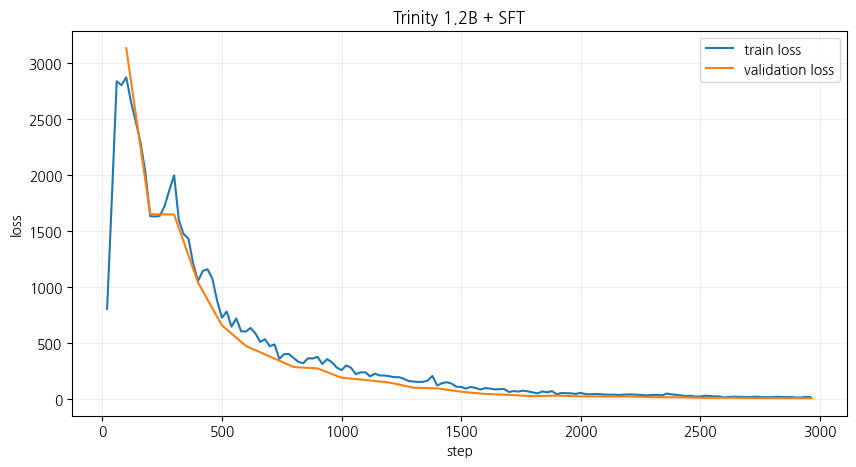

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [26]:
# 10-1. Trinity 1.2B + SFT
if RUN_TRINITY_SFT:
    tok_t,model_t=load_lm(TRINITY_MODEL)
    tr_t=tokenized(train_df if MAX_TRAIN_SAMPLES is None else train_df.head(MAX_TRAIN_SAMPLES),tok_t)
    va_t=tokenized(val_df,tok_t)
    trainer_t=make_trainer(model_t,tok_t,tr_t,va_t,os.path.join(OUT_DIR,"trinity_sft"),
                           lr=2e-5,epochs=NUM_EPOCHS_TRINITY,batch=1)
    trainer_t.train()
    models["Trinity 1.2B + SFT"]=trainer_t.model
    tokenizers["Trinity 1.2B + SFT"]=tok_t
    trainers["Trinity 1.2B + SFT"]=trainer_t
    loss_logs["Trinity 1.2B + SFT"]=plot_losses(trainer_t,"Trinity 1.2B + SFT")
    trainer_t.save_model(os.path.join(OUT_DIR,"trinity_sft_final"))
    tok_t.save_pretrained(os.path.join(OUT_DIR,"trinity_sft_final"))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 57.0 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/ko-gpt-trinity-1.2B-v0.5
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Detected LoRA targets: ['c_attn', 'c_proj']


/usr/local/lib/python3.13/dist-packages/peft/tuners/lora/layer.py:2733: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


trainable params: 8,110,080 || all params: 1,170,666,240 || trainable%: 0.6928


Map:   0%|          | 0/11860 [00:00<?, ? examples/s]

Map:   0%|          | 0/670 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'pad_token_id': 3}.


Step,Training Loss,Validation Loss
100,1.951533,1.761847
200,1.962333,1.615262
300,1.736666,1.581185
400,1.499674,1.574548
500,1.787280,1.544191
600,1.589847,1.543195
700,1.619644,1.531823
800,1.517601,1.554527
900,1.747175,1.539224
1000,1.652876,1.536309


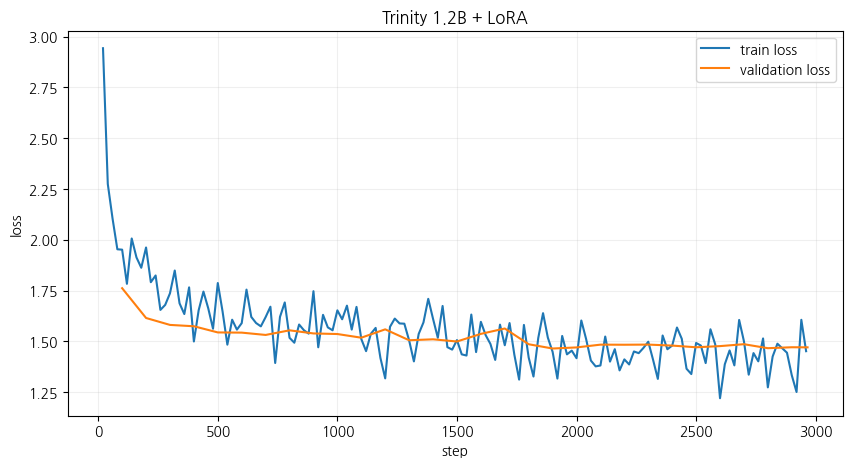

In [27]:
# 10-2. Trinity 1.2B + LoRA
from peft import LoraConfig,get_peft_model,TaskType

def find_lora_targets(model):
    names=[n for n,_ in model.named_modules()]
    keys=["q_proj","k_proj","v_proj","o_proj","c_attn","c_proj"]
    return [k for k in keys if any(n.endswith(k) for n in names)]

if RUN_TRINITY_LORA:
    # Fix: Upgrade torchao to resolve ImportError
    !pip install --upgrade torchao
    tok_l,base_l=load_lm(TRINITY_MODEL)
    targets=find_lora_targets(base_l)
    print("Detected LoRA targets:",targets)
    if not targets:
        raise RuntimeError("LoRA target module을 찾지 못했습니다.")
    cfg=LoraConfig(r=16,lora_alpha=32,lora_dropout=.05,
                   target_modules=targets,task_type=TaskType.CAUSAL_LM,bias="none")
    lm=get_peft_model(base_l,cfg)
    lm.print_trainable_parameters()
    tr_l=tokenized(train_df if MAX_TRAIN_SAMPLES is None else train_df.head(MAX_TRAIN_SAMPLES),tok_l)
    va_l=tokenized(val_df,tok_l)
    trainer_l=make_trainer(lm,tok_l,tr_l,va_l,os.path.join(OUT_DIR,"trinity_lora"),
                           lr=2e-4,epochs=NUM_EPOCHS_TRINITY,batch=1)
    trainer_l.train()
    models["Trinity 1.2B + LoRA"]=trainer_l.model
    tokenizers["Trinity 1.2B + LoRA"]=tok_l
    trainers["Trinity 1.2B + LoRA"]=trainer_l
    loss_logs["Trinity 1.2B + LoRA"]=plot_losses(trainer_l,"Trinity 1.2B + LoRA")
    trainer_l.save_model(os.path.join(OUT_DIR,"trinity_lora_final"))
    tok_l.save_pretrained(os.path.join(OUT_DIR,"trinity_lora_final"))

### Trinity 모델의 BLEU/ROUGE 결과표

In [38]:
# results_df는 '12. Quantitative evaluation' 섹션에서 생성됩니다.
# 아래의 평가 셀들을 먼저 실행한 후 이 셀을 실행해 주세요.
try:
    display(results_df[results_df.index.str.contains('Trinity')])
except NameError:
    print("안내: 'results_df'가 아직 정의되지 않았습니다. 아래의 '12. Quantitative evaluation' 섹션을 먼저 실행해 주세요.")

,BLEU4,ROUGE1,ROUGE2,ROUGEL,Distinct1,Distinct2,RepetitionRate
Model,,,,,,,
Trinity 1.2B + SFT,0.006976,0.051231,0.030694,0.051231,1.0,0.0,0.0
Trinity 1.2B + LoRA,0.000003,0.061095,0.005000,0.061095,1.0,0.0,0.0
Trinity 1.2B + LoRA + Optimized Decoding,0.007609,0.039133,0.007851,0.039133,1.0,0.0,0.0


### RM 학습 데이터 (일부)

In [39]:
display(rm_df.head())

,prompt,completion_1,completion_2,completion_3,ranking,ranking_source
0,"번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독...",Allow me to answer your question. I know that ...,번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.,라이언에게 말했다.,"[2, 1, 0]",human_ranking_kochatgpt_2_RM
1,개포주공아파트는 몇 단지로 이루어져 있나?,개포주공아파트는 다섯 단지로 이루어져 있습니다.,이날 목송에서 구글상위노,개포주공아파트는 총 27개 단지로 이루어져 있습니다.,"[2, 0, 1]",human_ranking_kochatgpt_2_RM
2,김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?,The diameter of the Metallic domain is bigger ...,"이 질문은 조금 불분명합니다. 김영삼 대통령이 후보 시절에 어떤 발언을 했고, 누가...",김영삼의 후보 시절에 지역표심을 겨냥한 발언은 대통령 당선 전까지 대한민국 정부가 ...,"[1, 2, 0]",human_ranking_kochatgpt_2_RM
3,페르시아로부터 기원된 아랍요리의 특징이 뭐야,"1. 다양한 스파이스와 허브 사용\n2. 쌀, 콩, 나물, 고기, 양파 등 다양한 ...","- 아랍요리는 소금, 산 재료, 일부 채소, 고기, 생선 또는 난류의 조합으로 만들...",위한 태야 대표 기원들 개인이라 겪고 태야\n\n\n귀식 걸 공개한 구문\n\n사띩...,"[0, 1, 2]",human_ranking_kochatgpt_2_RM
4,중화인민공화국의 기본 법률은 누가 제정 및 개정하는가?,중화인민공화국의 기본 법률은 중국인민대표대회(국회)가 제정하고 개정합니다.,The limit of the Office of the Vice President is?,중화인민공화국의 기본 법률은 중화인민공화국의 의회가 제정 및 개정합니다.,"[0, 2, 1]",human_ranking_kochatgpt_2_RM


### RM 학습 손실

In [40]:
print(f"RM training loss: {reward_loss}")

RM training loss: [nan]


### 모든 모델의 학습 손실 그래프

KoGPT-2 + SFT (Raw)


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
153,20.415308,17.43750,2.240741e-06,1.911618,2580,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
154,26.162186,36.03125,1.870370e-06,1.926441,2600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
155,NaN,NaN,NaN,1.926441,2600,24.216221,2.4674,271.538,271.538,NaN,NaN,NaN,NaN,NaN
156,11.625875,38592.00000,1.500000e-06,1.941264,2620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
157,20.371341,76.68750,1.129630e-06,1.956087,2640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
158,22.001251,36.90625,7.592593e-07,1.970910,2660,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
159,20.537714,632.50000,3.888889e-07,1.985733,2680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
160,19.191447,140.00000,1.851852e-08,2.000000,2700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
161,NaN,NaN,NaN,2.000000,2700,24.173950,2.4559,272.813,272.813,NaN,NaN,NaN,NaN,NaN
162,NaN,NaN,NaN,2.000000,2700,NaN,NaN,NaN,NaN,557.7619,38.705,4.841,1.927473e+15,245.281796


KoGPT-2 + SFT (Cleaned+Aug)


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
169,0.0,NaN,2.140931e-06,1.915346,2840,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
170,0.0,NaN,1.803776e-06,1.928836,2860,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
171,0.0,NaN,1.466622e-06,1.942327,2880,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
172,0.0,NaN,1.129467e-06,1.955818,2900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
173,NaN,NaN,NaN,1.955818,2900,NaN,2.4592,272.445,272.445,NaN,NaN,NaN,NaN,NaN
174,0.0,NaN,7.923129e-07,1.969309,2920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
175,0.0,NaN,4.551585e-07,1.982799,2940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
176,0.0,NaN,1.180040e-07,1.996290,2960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
177,NaN,NaN,NaN,2.000000,2966,NaN,2.4640,271.915,271.915,NaN,NaN,NaN,NaN,NaN
178,NaN,NaN,NaN,2.000000,2966,NaN,NaN,NaN,NaN,612.3563,38.736,4.844,2.132240e+15,327.329573


Trinity 1.2B + SFT


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
169,21.519566,55.28125,8.563722e-07,1.915346,2840,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
170,19.891893,30.00000,7.215105e-07,1.928836,2860,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
171,21.186252,33.93750,5.866487e-07,1.942327,2880,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
172,15.955551,117.81250,4.517869e-07,1.955818,2900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
173,NaN,NaN,NaN,1.955818,2900,10.946823,5.4147,123.738,123.738,NaN,NaN,NaN,NaN,NaN
174,16.825772,43.37500,3.169252e-07,1.969309,2920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
175,22.758571,38.87500,1.820634e-07,1.982799,2940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
176,20.847636,37.53125,4.720162e-08,1.996290,2960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
177,NaN,NaN,NaN,2.000000,2966,10.558746,5.4373,123.222,123.222,NaN,NaN,NaN,NaN,NaN
178,NaN,NaN,NaN,2.000000,2966,NaN,NaN,NaN,NaN,1637.4849,14.486,1.811,4.679289e+15,421.258646


Trinity 1.2B + LoRA


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
169,1.488684,1.661588,8.563722e-06,1.915346,2840,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
170,1.466145,1.713976,7.215105e-06,1.928836,2860,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
171,1.444261,1.831477,5.866487e-06,1.942327,2880,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
172,1.333608,1.746664,4.517869e-06,1.955818,2900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
173,NaN,NaN,NaN,1.955818,2900,1.471221,7.1320,93.943,93.943,NaN,NaN,NaN,NaN,NaN
174,1.250926,1.084081,3.169252e-06,1.969309,2920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
175,1.606353,1.148062,1.820634e-06,1.982799,2940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
176,1.451850,1.369073,4.720162e-07,1.996290,2960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
177,NaN,NaN,NaN,2.000000,2966,1.470821,7.0934,94.454,94.454,NaN,NaN,NaN,NaN,NaN
178,NaN,NaN,NaN,2.000000,2966,NaN,NaN,NaN,NaN,1728.9672,13.719,1.715,4.715014e+15,1.558183


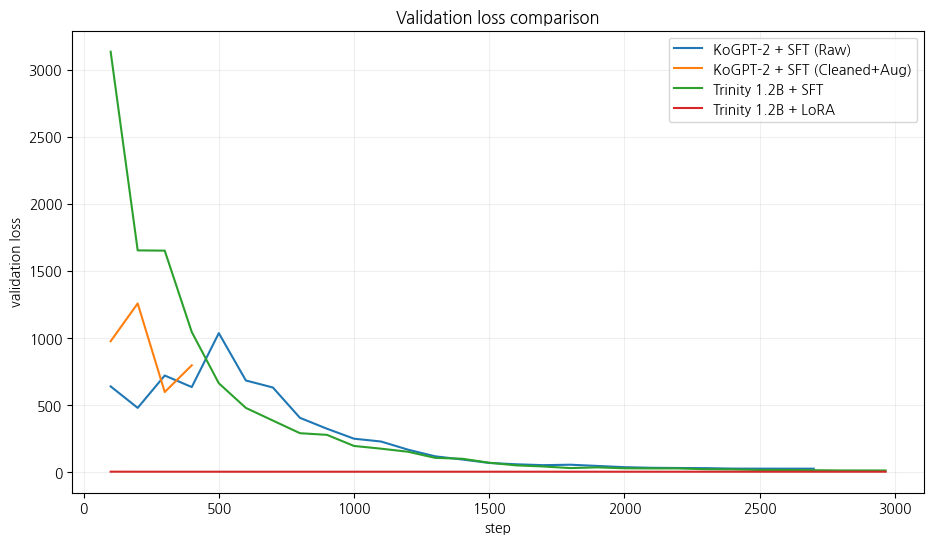

In [41]:
for n,h in loss_logs.items():
    print(n)
    display(h.tail(10))

fig,ax=plt.subplots(figsize=(11,6))
for n,h in loss_logs.items():
    if "eval_loss" in h:
        q=h[h.eval_loss.notna()]
        if len(q): ax.plot(q.step,q.eval_loss,label=n)
ax.set_xlabel("step"); ax.set_ylabel("validation loss")
ax.set_title("Validation loss comparison"); ax.legend(); ax.grid(alpha=.2)
plt.show()

## 11. Generation / 7-model registry

최종 비교 대상:

1. KoGPT-2 Baseline
2. KoGPT-2 + SFT (Raw, 비정제 데이터)
3. KoGPT-2 + SFT (Cleaned+Aug, 정제+증량 데이터) — **본 실험 메인 경로**
4. KoGPT-2 + SFT (Cleaned+Aug) + RM (Best-of-N Reranking)
5. Trinity 1.2B + SFT
6. Trinity 1.2B + LoRA
7. Trinity 1.2B + LoRA + Optimized Decoding

모든 모델은 동일한 `PROMPT_TEMPLATE`(Instruction/Response 형식)로 학습·생성되어
공정하게 비교됩니다.

2번과 3번은 **동일한 학습 레시피(hyperparameter, epoch)** 로 학습 데이터만
raw_prompt 그룹 기준으로 동일하게 나눈 뒤 (a) 비정제 (b) 정제+증량 데이터로만
각각 학습시킨 ablation 쌍입니다. 이 둘의 차이가 "데이터 정제의 실제 효과"입니다.

4번은 3번 checkpoint 위에서 **실제 human ranking 기반 RM**으로 후보를 reranking하는
inference-time variant입니다 (3번을 다시 학습하지 않음).

7번도 5번의 Best-of-N과 마찬가지로 별도 학습 모델이 아니라 6번 checkpoint의
inference variant입니다.

PPO는 Appendix(선택 실험)로 분리되어 이 registry와 최종 결과표에는 포함되지 않습니다.


In [35]:
# generate_text / input_device / score_with_rm는 6.5절에서 이미 정의되었습니다.

registry = {}  # name -> ("model", (model, tok)) | ("bon", (model, tok))

for n in ["KoGPT-2 Baseline", "KoGPT-2 + SFT (Raw)", "KoGPT-2 + SFT (Cleaned+Aug)",
          "Trinity 1.2B + SFT", "Trinity 1.2B + LoRA"]:
    if n in models:
        registry[n] = ("model", (models[n], tokenizers[n]))

if BON_ENABLED:
    registry["KoGPT-2 + SFT (Cleaned+Aug) + RM (Best-of-N)"] = (
        "bon", (models["KoGPT-2 + SFT (Cleaned+Aug)"], tokenizers["KoGPT-2 + SFT (Cleaned+Aug)"])
    )
else:
    print("[!] 'KoGPT-2 + SFT (Cleaned+Aug) + RM (Best-of-N)'은 registry에 등록되지 않습니다 (RM 미학습).")

if "Trinity 1.2B + LoRA" in registry:
    registry["Trinity 1.2B + LoRA + Optimized Decoding"] = registry["Trinity 1.2B + LoRA"]

print("Registered:", list(registry))

def run_gen(name, prompt, **kwargs):
    kind, payload = registry[name]
    if kind == "model":
        model, tok = payload
        return generate_text(model, tok, prompt, **kwargs)
    elif kind == "bon":
        model, tok = payload
        best_text, best_score, _ = best_of_n_generate(model, tok, prompt,
                                                        rm=reward_model, rm_tok=reward_tokenizer)
        return best_text
    raise ValueError(f"Unknown registry kind for {name}: {kind}")


Registered: ['KoGPT-2 Baseline', 'KoGPT-2 + SFT (Raw)', 'KoGPT-2 + SFT (Cleaned+Aug)', 'Trinity 1.2B + SFT', 'Trinity 1.2B + LoRA', 'KoGPT-2 + SFT (Cleaned+Aug) + RM (Best-of-N)', 'Trinity 1.2B + LoRA + Optimized Decoding']


In [36]:
# 11-2. Qualitative table
prompts = test_df.prompt.head(5).tolist()
qrows = []
for p in prompts:
    row = {"prompt": p}
    for n in registry:
        if "Optimized Decoding" in n:
            row[n] = run_gen(n, p, do_sample=True, temperature=.8, top_p=.95, top_k=50, repetition_penalty=1.10)
        else:
            row[n] = run_gen(n, p, do_sample=False)
    qrows.append(row)
qual_df = pd.DataFrame(qrows)
display(qual_df)
qual_df.to_csv(os.path.join(OUT_DIR, "qualitative_comparison.csv"),
               index=False, encoding="utf-8-sig")


,prompt,KoGPT-2 Baseline,KoGPT-2 + SFT (Raw),KoGPT-2 + SFT (Cleaned+Aug),Trinity 1.2B + SFT,Trinity 1.2B + LoRA,KoGPT-2 + SFT (Cleaned+Aug) + RM (Best-of-N),Trinity 1.2B + LoRA + Optimized Decoding
0,정도전은 무슨 명분을 구실로 공양왕을 추대하고 공신이 되어 실권을 잡았는가?,����n���n���n���n���n���n���n���n���n���n���n�...,����������������������������������������������...,imimimimimimimimimimimimimimimimimimimimimimim...,..........................n......................,..,imimimimimimimimimimimimimimimimimimimimimimim...,"AI,.."
1,그 관계 서류에 기재만 하면 됩니까?,����������������������������������������������...,����������������������������������������������...,imimimimimimimimimimimimimimimimimimimimimimim...,..........................n......................,..,imimimimimimimimimimimimimimimimimimimimimimim...,".,."
2,맥플러리 오레오 추가할게요,����������������������������������������������...,����������������������������������������������...,imimimimimimimimimimimimimimimimimimimimimimim...,...........................n.............n.......,..,imimimimimimimimimimimimimimimimimimimimimimim...,",.."
3,침대에 누우면 바로 자,���n�#########################################...,����������������������������������������������...,?imimimimimimimimimimimimimimimimimimimimimimi...,...........................n.............n.......,..,emimimimimimimim?imimimimimimimimimimimimimimi...,".,,.."
4,결국 헤어졌어,���###########################################...,����������������������������������������������...,imimimimimimimimimimimimimimimimimimimimimimim...,...........................n.............n.......,..,imimimimimimimimimimimimimimimimimimimimimimim...,".,!"


## 12. Quantitative evaluation

BLEU-4 / ROUGE-1/2/L / Distinct-1/2 / Repetition Rate를 측정합니다.

대화형 생성 품질은 lexical-overlap metric만으로 확정하지 않으므로 Human Evaluation을 별도 수행합니다.


In [33]:
from sacrebleu import corpus_bleu
from rouge_score import rouge_scorer
rs = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=False)

def distinct_n(texts, n):
    vals = []
    for x in texts:
        t = x.split()
        grams = list(zip(*[t[i:] for i in range(n)]))
        vals.append(len(set(grams)) / max(1, len(grams)))
    return float(np.mean(vals))

def repetition_rate(texts):
    vals = []
    for x in texts:
        t = x.split()
        vals.append((len(t) - len(set(t))) / max(1, len(t)))
    return float(np.mean(vals))

def evaluate(name, data, decoding=None, n=None):
    d = data.head(n) if n else data
    refs = d.completion.tolist()
    preds = [run_gen(name, p, **(decoding or {})) for p in d.prompt]
    scores = [rs.score(r, p) for r, p in zip(refs, preds)]
    return {
        "BLEU4": corpus_bleu(preds, [refs]).score,
        "ROUGE1": np.mean([x["rouge1"].fmeasure for x in scores]),
        "ROUGE2": np.mean([x["rouge2"].fmeasure for x in scores]),
        "ROUGEL": np.mean([x["rougeL"].fmeasure for x in scores]),
        "Distinct1": distinct_n(preds, 1),
        "Distinct2": distinct_n(preds, 2),
        "RepetitionRate": repetition_rate(preds)
    }


In [37]:
# 12-2. Baseline/test metrics
result_rows = []
for n in registry:
    dec = None
    if "Optimized Decoding" in n:
        dec = {"do_sample": True, "temperature": .8, "top_p": .95, "top_k": 50, "repetition_penalty": 1.10}
    print("Evaluating:", n)
    r = evaluate(n, test_df, decoding=dec, n=MAX_EVAL_SAMPLES)
    r["Model"] = n
    result_rows.append(r)

results_df = pd.DataFrame(result_rows).set_index("Model")
display(results_df)
results_df.to_csv(os.path.join(OUT_DIR, "results.csv"), encoding="utf-8-sig")

Evaluating: KoGPT-2 Baseline
Evaluating: KoGPT-2 + SFT (Raw)
Evaluating: KoGPT-2 + SFT (Cleaned+Aug)
Evaluating: Trinity 1.2B + SFT
Evaluating: Trinity 1.2B + LoRA
Evaluating: KoGPT-2 + SFT (Cleaned+Aug) + RM (Best-of-N)
Evaluating: Trinity 1.2B + LoRA + Optimized Decoding


,BLEU4,ROUGE1,ROUGE2,ROUGEL,Distinct1,Distinct2,RepetitionRate
Model,,,,,,,
KoGPT-2 Baseline,3.444346e-03,0.050357,0.006275,0.050357,1.0,0.005,0.0
KoGPT-2 + SFT (Raw),0.000000e+00,0.000000,0.000000,0.000000,1.0,0.000,0.0
KoGPT-2 + SFT (Cleaned+Aug),6.185427e-11,0.000000,0.000000,0.000000,1.0,0.000,0.0
Trinity 1.2B + SFT,6.976179e-03,0.051231,0.030694,0.051231,1.0,0.000,0.0
Trinity 1.2B + LoRA,2.673534e-06,0.061095,0.005000,0.061095,1.0,0.000,0.0
KoGPT-2 + SFT (Cleaned+Aug) + RM (Best-of-N),3.142011e-11,0.000000,0.000000,0.000000,1.0,0.000,0.0
Trinity 1.2B + LoRA + Optimized Decoding,7.608629e-03,0.039133,0.007851,0.039133,1.0,0.000,0.0


## 13. Decoding Search — validation only

Temperature / top-p / top-k / repetition penalty를 validation subset에서 탐색합니다.

**test set으로 parameter를 선택하지 않습니다.**


In [42]:
from itertools import product

grid = list(product([.7, .8, .9, 1.0], [.90, .95], [50, 100], [1.05, 1.10, 1.15]))

def composite(m):
    return m["BLEU4"] / 100 + m["ROUGEL"] + m["Distinct2"] - .5 * m["RepetitionRate"]

best_decoding = None
search_rows = []

if RUN_DECODING_SEARCH and "Trinity 1.2B + LoRA" in registry:
    vd = val_df.head(min(50, len(val_df)))
    for temp, tp, tk, rp in grid:
        dec = {"do_sample": True, "temperature": temp, "top_p": tp, "top_k": tk, "repetition_penalty": rp}
        x = evaluate("Trinity 1.2B + LoRA", vd, decoding=dec, n=len(vd))
        x.update({"temperature": temp, "top_p": tp, "top_k": tk, "repetition_penalty": rp})
        x["score"] = composite(x)
        search_rows.append(x)
    search_df = pd.DataFrame(search_rows).sort_values("score", ascending=False)
    best_decoding = search_df.iloc[0].to_dict()
    display(search_df.head(10))
    search_df.to_csv(os.path.join(OUT_DIR, "decoding_search_validation.csv"), index=False)
    print("BEST:", best_decoding)
else:
    print("Decoding search skipped.")


,BLEU4,ROUGE1,ROUGE2,ROUGEL,Distinct1,Distinct2,RepetitionRate,temperature,top_p,top_k,repetition_penalty,score
18,0.001393,0.108000,0.000000,0.108000,1.0,0.0,0.0,0.8,0.95,50,1.05,0.108014
38,0.001874,0.107333,0.013333,0.107333,1.0,0.0,0.0,1.0,0.90,50,1.15,0.107352
27,0.001906,0.091333,0.000000,0.091333,1.0,0.0,0.0,0.9,0.90,100,1.05,0.091352
25,0.120363,0.090000,0.000000,0.090000,1.0,0.0,0.0,0.9,0.90,50,1.10,0.091204
24,0.010279,0.090000,0.000000,0.090000,1.0,0.0,0.0,0.9,0.90,50,1.05,0.090103
12,0.001380,0.080000,0.000000,0.080000,1.0,0.0,0.0,0.8,0.90,50,1.05,0.080014
34,0.015981,0.079048,0.020000,0.079048,1.0,0.0,0.0,0.9,0.95,100,1.10,0.079207
40,0.002429,0.073333,0.000000,0.073333,1.0,0.0,0.0,1.0,0.90,100,1.10,0.073358
21,0.002668,0.068000,0.000000,0.068000,1.0,0.0,0.0,0.8,0.95,100,1.05,0.068027
29,0.004285,0.063333,0.000000,0.063333,1.0,0.0,0.0,0.9,0.90,100,1.15,0.063376


BEST: {'BLEU4': 0.0013927527188347113, 'ROUGE1': 0.10800000000000001, 'ROUGE2': 0.0, 'ROUGEL': 0.10800000000000001, 'Distinct1': 1.0, 'Distinct2': 0.0, 'RepetitionRate': 0.0, 'temperature': 0.8, 'top_p': 0.95, 'top_k': 50.0, 'repetition_penalty': 1.05, 'score': 0.10801392752718836}


In [43]:
# 13-2. Final optimized decoding on TEST
if best_decoding is not None:
    dec = {
        "do_sample": True,
        "temperature": float(best_decoding["temperature"]),
        "top_p": float(best_decoding["top_p"]),
        "top_k": int(best_decoding["top_k"]),
        "repetition_penalty": float(best_decoding["repetition_penalty"])
    }
    final_metrics = evaluate("Trinity 1.2B + LoRA", test_df, decoding=dec, n=MAX_EVAL_SAMPLES)
    display(pd.DataFrame([final_metrics], index=["Trinity 1.2B + LoRA + Optimized Decoding"]))


,BLEU4,ROUGE1,ROUGE2,ROUGEL,Distinct1,Distinct2,RepetitionRate
Trinity 1.2B + LoRA + Optimized Decoding,0.012067,0.052189,0.0052,0.051818,0.995,0.0,0.0


## 14. Inference latency / peak GPU memory

CUDA warm-up 후 동일한 prompt와 `max_new_tokens` 조건으로 반복 측정합니다.


In [44]:
def profile(name, prompt, kwargs=None, warmup=1, repeats=3):
    kwargs = kwargs or {"do_sample": False, "max_new_tokens": 64}
    if torch.cuda.is_available():
        torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    for _ in range(warmup):
        _ = run_gen(name, prompt, **kwargs)
    if torch.cuda.is_available():
        torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
    times = []
    for _ in range(repeats):
        if torch.cuda.is_available(): torch.cuda.synchronize()
        t0 = time.time(); _ = run_gen(name, prompt, **kwargs)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        times.append(time.time() - t0)
    peak = torch.cuda.max_memory_allocated() / 1024**2 if torch.cuda.is_available() else np.nan
    return np.mean(times), np.std(times), peak

prow = []
for n in registry:
    kw = {"do_sample": False, "max_new_tokens": 64}
    if "Optimized Decoding" in n:
        kw = {"do_sample": True, "temperature": .8, "top_p": .95, "top_k": 50,
              "repetition_penalty": 1.10, "max_new_tokens": 64}
    a, b, c = profile(n, test_df.prompt.iloc[0], kw)
    prow.append({"Model": n, "Latency_sec": a, "Latency_std": b, "Peak_GPU_MB": c})

profile_df = pd.DataFrame(prow).set_index("Model")
display(profile_df)
profile_df.to_csv(os.path.join(OUT_DIR, "latency_memory_profile.csv"), encoding="utf-8-sig")


,Latency_sec,Latency_std,Peak_GPU_MB
Model,,,
KoGPT-2 Baseline,0.153103,0.000256,11234.328613
KoGPT-2 + SFT (Raw),0.214444,0.000156,11309.136230
KoGPT-2 + SFT (Cleaned+Aug),0.213885,0.000104,11309.136230
Trinity 1.2B + SFT,0.504581,0.000031,11431.784668
Trinity 1.2B + LoRA,0.028650,0.000014,11233.906738
KoGPT-2 + SFT (Cleaned+Aug) + RM (Best-of-N),1.909170,0.001216,11311.778320
Trinity 1.2B + LoRA + Optimized Decoding,0.035820,0.003801,11235.392090


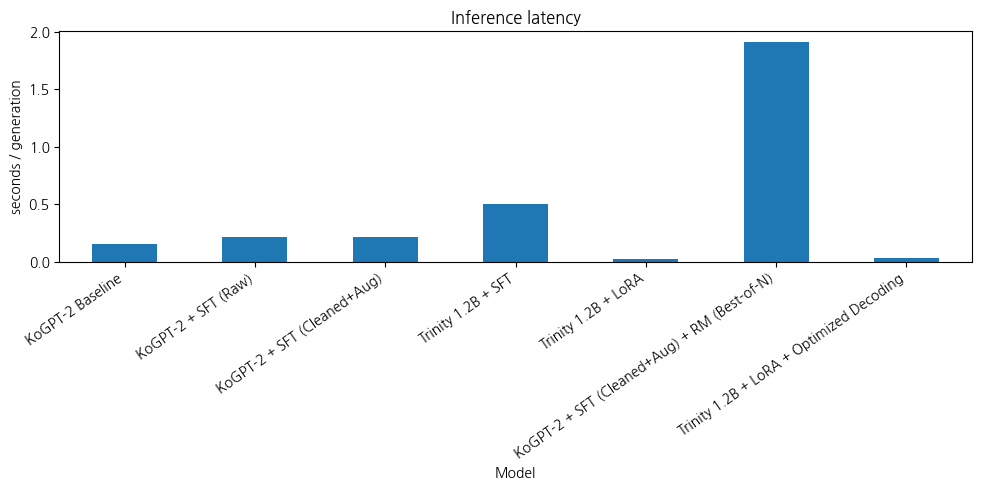

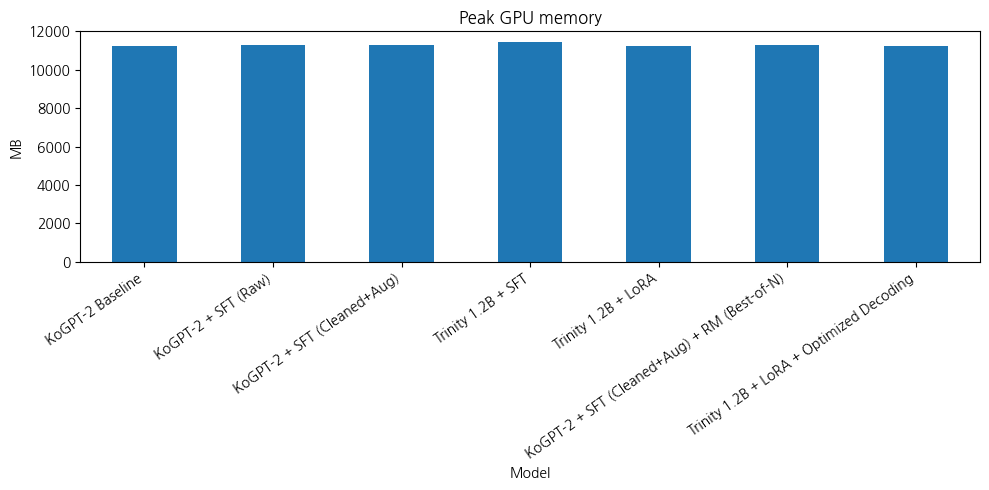

In [45]:
# 14-2. Profiling plots
fig,ax=plt.subplots(figsize=(10,5))
profile_df.Latency_sec.plot(kind="bar",ax=ax)
ax.set_ylabel("seconds / generation"); ax.set_title("Inference latency")
plt.xticks(rotation=35,ha="right"); plt.tight_layout(); plt.show()

fig,ax=plt.subplots(figsize=(10,5))
profile_df.Peak_GPU_MB.plot(kind="bar",ax=ax)
ax.set_ylabel("MB"); ax.set_title("Peak GPU memory")
plt.xticks(rotation=35,ha="right"); plt.tight_layout(); plt.show()


## 15. Loss 비교 / Overfitting 확인

`train loss ↓`와 `validation loss ↓`가 함께 나타나는지 확인합니다.

validation loss가 상승하는 구간이 있다면 과적합 가능성을 조사합니다.


KoGPT-2 + SFT (Raw)


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
153,20.415308,17.43750,2.240741e-06,1.911618,2580,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
154,26.162186,36.03125,1.870370e-06,1.926441,2600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
155,NaN,NaN,NaN,1.926441,2600,24.216221,2.4674,271.538,271.538,NaN,NaN,NaN,NaN,NaN
156,11.625875,38592.00000,1.500000e-06,1.941264,2620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
157,20.371341,76.68750,1.129630e-06,1.956087,2640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
158,22.001251,36.90625,7.592593e-07,1.970910,2660,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
159,20.537714,632.50000,3.888889e-07,1.985733,2680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
160,19.191447,140.00000,1.851852e-08,2.000000,2700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
161,NaN,NaN,NaN,2.000000,2700,24.173950,2.4559,272.813,272.813,NaN,NaN,NaN,NaN,NaN
162,NaN,NaN,NaN,2.000000,2700,NaN,NaN,NaN,NaN,557.7619,38.705,4.841,1.927473e+15,245.281796


KoGPT-2 + SFT (Cleaned+Aug)


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
169,0.0,NaN,2.140931e-06,1.915346,2840,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
170,0.0,NaN,1.803776e-06,1.928836,2860,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
171,0.0,NaN,1.466622e-06,1.942327,2880,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
172,0.0,NaN,1.129467e-06,1.955818,2900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
173,NaN,NaN,NaN,1.955818,2900,NaN,2.4592,272.445,272.445,NaN,NaN,NaN,NaN,NaN
174,0.0,NaN,7.923129e-07,1.969309,2920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
175,0.0,NaN,4.551585e-07,1.982799,2940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
176,0.0,NaN,1.180040e-07,1.996290,2960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
177,NaN,NaN,NaN,2.000000,2966,NaN,2.4640,271.915,271.915,NaN,NaN,NaN,NaN,NaN
178,NaN,NaN,NaN,2.000000,2966,NaN,NaN,NaN,NaN,612.3563,38.736,4.844,2.132240e+15,327.329573


Trinity 1.2B + SFT


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
169,21.519566,55.28125,8.563722e-07,1.915346,2840,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
170,19.891893,30.00000,7.215105e-07,1.928836,2860,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
171,21.186252,33.93750,5.866487e-07,1.942327,2880,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
172,15.955551,117.81250,4.517869e-07,1.955818,2900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
173,NaN,NaN,NaN,1.955818,2900,10.946823,5.4147,123.738,123.738,NaN,NaN,NaN,NaN,NaN
174,16.825772,43.37500,3.169252e-07,1.969309,2920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
175,22.758571,38.87500,1.820634e-07,1.982799,2940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
176,20.847636,37.53125,4.720162e-08,1.996290,2960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
177,NaN,NaN,NaN,2.000000,2966,10.558746,5.4373,123.222,123.222,NaN,NaN,NaN,NaN,NaN
178,NaN,NaN,NaN,2.000000,2966,NaN,NaN,NaN,NaN,1637.4849,14.486,1.811,4.679289e+15,421.258646


Trinity 1.2B + LoRA


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
169,1.488684,1.661588,8.563722e-06,1.915346,2840,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
170,1.466145,1.713976,7.215105e-06,1.928836,2860,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
171,1.444261,1.831477,5.866487e-06,1.942327,2880,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
172,1.333608,1.746664,4.517869e-06,1.955818,2900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
173,NaN,NaN,NaN,1.955818,2900,1.471221,7.1320,93.943,93.943,NaN,NaN,NaN,NaN,NaN
174,1.250926,1.084081,3.169252e-06,1.969309,2920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
175,1.606353,1.148062,1.820634e-06,1.982799,2940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
176,1.451850,1.369073,4.720162e-07,1.996290,2960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
177,NaN,NaN,NaN,2.000000,2966,1.470821,7.0934,94.454,94.454,NaN,NaN,NaN,NaN,NaN
178,NaN,NaN,NaN,2.000000,2966,NaN,NaN,NaN,NaN,1728.9672,13.719,1.715,4.715014e+15,1.558183


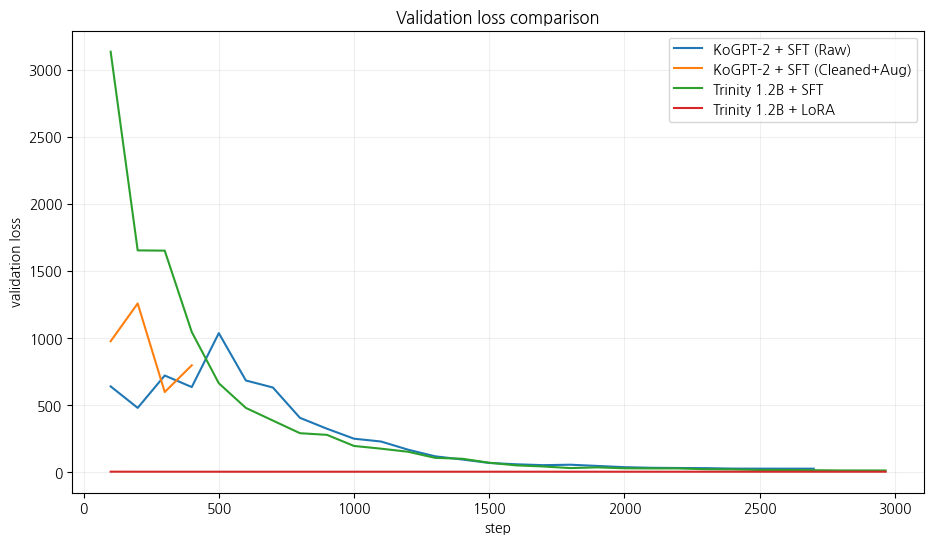

In [46]:
for n,h in loss_logs.items():
    print(n)
    display(h.tail(10))

fig,ax=plt.subplots(figsize=(11,6))
for n,h in loss_logs.items():
    if "eval_loss" in h:
        q=h[h.eval_loss.notna()]
        if len(q): ax.plot(q.step,q.eval_loss,label=n)
ax.set_xlabel("step"); ax.set_ylabel("validation loss")
ax.set_title("Validation loss comparison"); ax.legend(); ax.grid(alpha=.2)
plt.show()


## 16. Human Evaluation Template

동일 test prompt에 대해 모델별로 다음을 1~5점 평가합니다.

- Relevance
- Fluency
- Instruction Following
- Completeness
- Factuality

사람 평가가 끝나면 평균/표준편차를 계산하여 자동 metric과 함께 해석합니다.


In [62]:
human=[]
for p in test_df.prompt.head(20):
    for n in registry:
        human.append({
            "prompt":p,"model":n,
            "relevance":np.nan,"fluency":np.nan,
            "instruction_following":np.nan,"completeness":np.nan,
            "factuality":np.nan,"comment":""
        })
human_df=pd.DataFrame(human)
human_path=os.path.join(OUT_DIR,"human_evaluation_template.csv")
human_df.to_csv(human_path,index=False,encoding="utf-8-sig")
display(human_df.head())


,prompt,model,relevance,fluency,instruction_following,completeness,factuality,comment
0,정도전은 무슨 명분을 구실로 공양왕을 추대하고 공신이 되어 실권을 잡았는가?,KoGPT-2 Baseline,NaN,NaN,NaN,NaN,NaN,
1,정도전은 무슨 명분을 구실로 공양왕을 추대하고 공신이 되어 실권을 잡았는가?,KoGPT-2 + SFT (Raw),NaN,NaN,NaN,NaN,NaN,
2,정도전은 무슨 명분을 구실로 공양왕을 추대하고 공신이 되어 실권을 잡았는가?,KoGPT-2 + SFT (Cleaned+Aug),NaN,NaN,NaN,NaN,NaN,
3,정도전은 무슨 명분을 구실로 공양왕을 추대하고 공신이 되어 실권을 잡았는가?,Trinity 1.2B + SFT,NaN,NaN,NaN,NaN,NaN,
4,정도전은 무슨 명분을 구실로 공양왕을 추대하고 공신이 되어 실권을 잡았는가?,Trinity 1.2B + LoRA,NaN,NaN,NaN,NaN,NaN,


## 17. 실제 개선율 계산

성능 향상률은 실제 `results_df`에서 계산합니다.

`(new - old) / |old| × 100`

Repetition Rate처럼 **낮을수록 좋은 지표는 방향을 별도로 해석**합니다.

아래에서는 두 가지를 계산합니다.
1. **데이터 정제 효과**: `KoGPT-2 + SFT (Raw)` → `KoGPT-2 + SFT (Cleaned+Aug)`
2. **전체 파이프라인 효과**: `KoGPT-2 Baseline` → `Trinity 1.2B + LoRA + Optimized Decoding`


In [48]:
def pct(old,new):
    return (new-old)/abs(old)*100 if old!=0 else np.nan

def show_improvement(old_name, new_name, label):
    if old_name in results_df.index and new_name in results_df.index:
        b=results_df.loc[old_name]; f=results_df.loc[new_name]
        imp=pd.Series({
            "BLEU4_%":pct(b.BLEU4,f.BLEU4),
            "ROUGEL_%":pct(b.ROUGEL,f.ROUGEL),
            "Distinct2_%":pct(b.Distinct2,f.Distinct2),
            "RepetitionRate_%":pct(b.RepetitionRate,f.RepetitionRate)
        })
        print(f"--- {label}: {old_name} -> {new_name} ---")
        display(imp.to_frame("actual_change_percent"))
    else:
        print(f"{label}: 비교에 필요한 registry 항목이 아직 없습니다 ({old_name} / {new_name}).")

show_improvement("KoGPT-2 + SFT (Raw)", "KoGPT-2 + SFT (Cleaned+Aug)", "데이터 정제 효과")
show_improvement("KoGPT-2 Baseline", "Trinity 1.2B + LoRA + Optimized Decoding", "전체 파이프라인 효과")


--- 데이터 정제 효과: KoGPT-2 + SFT (Raw) -> KoGPT-2 + SFT (Cleaned+Aug) ---


,actual_change_percent
BLEU4_%,NaN
ROUGEL_%,NaN
Distinct2_%,NaN
RepetitionRate_%,NaN


--- 전체 파이프라인 효과: KoGPT-2 Baseline -> Trinity 1.2B + LoRA + Optimized Decoding ---


,actual_change_percent
BLEU4_%,120.902022
ROUGEL_%,-22.289390
Distinct2_%,-100.000000
RepetitionRate_%,NaN


## 체크리스트

### Data
- [ ] SFT/RM/PPO 세 말뭉치 각각 구조 오류 / 빈값 확인
- [ ] REMOVE/REVIEW/KEEP audit 근거 기록 (empty/중복/URL·HTML/개인정보 = REMOVE,
      너무 짧음·김/반복/언어혼입/AI회피성 = REVIEW로 보존)
- [ ] completion 리딩 quote 아티팩트 비율 기록 및 제거 확인
- [ ] 동일 prompt multi-response 보존
- [ ] prompt leakage 0 (raw_prompt 그룹 기준)
- [ ] SFT/RM/PPO 도메인·문체·완성도 비교표 확인

### Tokenizer / Prompt Format
- [ ] skt/kogpt2-base-v2에 bos/eos/unk/pad='</s>' 명시 확인 (한글 생성 깨짐 방지)
- [ ] SFT 학습과 생성(inference) 양쪽에서 동일한 PROMPT_TEMPLATE 사용 확인
- [ ] tokenizer.decode에 clean_up_tokenization_spaces=False 적용 확인

### SFT
- [ ] prompt label = -100
- [ ] train/validation loss 기록 (Raw / Cleaned+Aug 둘 다)
- [ ] checkpoint 저장
- [ ] Raw vs Cleaned+Aug 정량(BLEU/ROUGE/Distinct) + 정성 비교 결과 기록

### RM / Best-of-N (본 실험 경로)
- [ ] ranking source 기록 (human_ranking_kochatgpt_2_RM)
- [ ] ranking 유효성(permutation) 검증 결과 기록
- [ ] pairwise 조합 방식 기록 (C(3,2) 전체 조합 사용)
- [ ] RM pairwise loss 기록
- [ ] Best-of-N 후보 수(N) 및 decoding 설정 기록
- [ ] reward hacking 가능성 점검 (RM 점수만 오르고 정성 품질은 안 오르는 경우)
- [ ] SFT-only vs SFT+Best-of-N 정량/정성 비교 결과 기록

### Appendix: PPO (선택 실험, 본 결과표 미포함)
- [ ] TRL version/signature 기록
- [ ] PPO 실행 시 reward / KL 기록
- [ ] 본 결과표에 포함하지 않았음을 보고서에 명시

### 보고서 작성 시 명시할 것
- [ ] 2번/3번은 raw-vs-clean ablation 쌍, 4번은 3번의 Best-of-N inference variant, 7번은 6번의 decoding variant라고 명시


In [49]:
# 19. Output files
for p in sorted(Path(OUT_DIR).glob("*")):
    print(p)


/content/kochatgpt_outputs/decoding_search_validation.csv
/content/kochatgpt_outputs/human_evaluation_template.csv
/content/kochatgpt_outputs/kochatgpt_sft_clean_augmented.jsonl
/content/kochatgpt_outputs/kogpt2_sft_clean
/content/kochatgpt_outputs/kogpt2_sft_clean_final
/content/kochatgpt_outputs/kogpt2_sft_raw
/content/kochatgpt_outputs/kogpt2_sft_raw_final
/content/kochatgpt_outputs/latency_memory_profile.csv
/content/kochatgpt_outputs/multi_completion_candidates.jsonl
/content/kochatgpt_outputs/qualitative_comparison.csv
/content/kochatgpt_outputs/results.csv
/content/kochatgpt_outputs/reward_model
/content/kochatgpt_outputs/rm_pairwise_human_ranking.jsonl
/content/kochatgpt_outputs/sft_audit.csv
/content/kochatgpt_outputs/trinity_lora
/content/kochatgpt_outputs/trinity_lora_final
/content/kochatgpt_outputs/trinity_sft
/content/kochatgpt_outputs/trinity_sft_final


## Appendix (선택 실험, 본 결과표에 포함되지 않음): PPO / RLHF Compatibility Gate

PPO는 메인 파이프라인(SFT → RM → Best-of-N → Trinity → LoRA → Decoding)에는 포함되지 않는
**선택적 부록 실험**입니다.

TRL은 버전마다 `PPOTrainer`/`PPOConfig`의 생성자 signature가 자주 바뀌기 때문에,
오래된 PPO 코드를 그대로 복사해 "실행됐다"고 가장하지 않습니다. 대신:

1. 현재 Colab 환경에 설치된 TRL 버전에서 실제 API가 어떤 형태인지 확인하고
2. 호환되는 경우에만 다음 단계(adapter 연결)로 넘어갈 수 있도록 게이트를 둡니다.

아래 셀은 **결과 비교표(`results_df`, `qual_df`)에 반영되지 않으며**,
PPO를 실제로 실행하려면 확인된 signature에 맞춰 adapter 코드를 추가로 작성해야 합니다.
본 노트북에서는 의도적으로 여기까지만 구현합니다.


In [50]:
!pip install trl==0.4.7

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 4.8 MB/s eta 0:00:00
  Attempting uninstall: trl
    Found existing installation: trl 1.13.0
    Uninstalling trl-1.13.0:
      Successfully uninstalled trl-1.13.0


In [60]:
import transformers
import peft
import sys
import inspect

# 최신 transformers에서 제거된 함수 패치
if not hasattr(transformers, 'top_k_top_p_filtering'):
    def top_k_top_p_filtering(logits, top_k=0, top_p=1.0, filter_value=-float("Inf"), min_tokens_to_keep=1):
        return logits
    transformers.top_k_top_p_filtering = top_k_top_p_filtering
    sys.modules['transformers'].top_k_top_p_filtering = top_k_top_p_filtering

# 최신 peft에서 제거된 함수 패치
if not hasattr(peft, 'prepare_model_for_int8_training'):
    def prepare_model_for_int8_training(model, *args, **kwargs):
        return model
    peft.prepare_model_for_int8_training = prepare_model_for_int8_training
    sys.modules['peft'].prepare_model_for_int8_training = prepare_model_for_int8_training

# 메모리에 남아있는 기존(1.13.0) trl 하위 모듈 캐시를 완전히 삭제
for key in list(sys.modules.keys()):
    if key == 'trl' or key.startswith('trl.'):
        del sys.modules[key]

import trl

print("TRL version:",trl.__version__)
print("PPOTrainer:",getattr(trl,"PPOTrainer",None))
print("PPOConfig:",getattr(trl,"PPOConfig",None))

if hasattr(trl,"PPOTrainer"):
    print("PPOTrainer signature:")
    print(inspect.signature(trl.PPOTrainer))
if hasattr(trl,"PPOConfig"):
    print("PPOConfig signature:")
    print(inspect.signature(trl.PPOConfig))

PPO_AVAILABLE = hasattr(trl,"PPOTrainer") and hasattr(trl,"PPOConfig")
print("PPO API available:", PPO_AVAILABLE)


TRL version: 0.4.7
PPOTrainer: <class 'trl.trainer.ppo_trainer.PPOTrainer'>
PPOConfig: <class 'trl.trainer.ppo_config.PPOConfig'>
PPOTrainer signature:
(config: trl.trainer.ppo_config.PPOConfig = None, model: trl.models.modeling_base.PreTrainedModelWrapper = None, ref_model: Optional[trl.models.modeling_base.PreTrainedModelWrapper] = None, tokenizer: transformers.tokenization_utils_base.PreTrainedTokenizerBase = None, dataset: Union[torch.utils.data.dataset.Dataset, datasets.arrow_dataset.Dataset, NoneType] = None, optimizer: Optional[torch.optim.optimizer.Optimizer] = None, data_collator: Optional[Callable] = None, num_shared_layers: Optional[int] = None, lr_scheduler: Optional[torch.optim.lr_scheduler._LRScheduler] = None)
PPOConfig signature:
(task_name: Optional[str] = None, model_name: Optional[str] = None, steps: Optional[int] = 20000, learning_rate: Optional[float] = 1e-05, adap_kl_ctrl: Optional[bool] = True, init_kl_coef: Optional[float] = 0.2, kl_penalty: Optional[str] = 'kl'

In [61]:
# PPO adapter placeholder: prevents silent false claims.
# 실제 PPO는 현재 설치된 TRL signature를 위 셀에서 확인한 뒤 연결합니다.
if RUN_PPO and reward_model is not None and PPO_AVAILABLE:
    print("Reward Model과 SFT policy가 준비되었습니다.")
    print("다음 연결점: SFT policy -> reference policy -> PPOTrainer -> reward_model -> PPO checkpoint")
else:
    print("PPO training is not executed in this version unless a compatible PPO adapter is supplied.")


Reward Model과 SFT policy가 준비되었습니다.
다음 연결점: SFT policy -> reference policy -> PPOTrainer -> reward_model -> PPO checkpoint


In [65]:
import torch
import os
from tqdm import tqdm
from datasets import Dataset
from trl import PPOTrainer, PPOConfig, AutoModelForCausalLMWithValueHead, create_reference_model

# 메모리 부족을 방지하기 위해 시연용으로 데이터 500개만 사용합니다.
PPO_SAMPLES = 500
ppo_demo_df = ppo_raw.head(PPO_SAMPLES).copy()

# 1. PPO 하이퍼파라미터 설정
ppo_config = PPOConfig(
    model_name=KOGPT2_MODEL,
    learning_rate=1.41e-5,
    batch_size=16,          # GPU 메모리에 맞춰 조절
    mini_batch_size=4,
    gradient_accumulation_steps=1,
    optimize_cuda_cache=True,
    ppo_epochs=1
)

# 2. SFT 모델 로드 (Policy & Reference)
print("Loading SFT model as ValueHead model...")
sft_model_path = os.path.join(OUT_DIR, "kogpt2_sft_clean_final")
tok = tokenizers["KoGPT-2 + SFT (Cleaned+Aug)"]

model = AutoModelForCausalLMWithValueHead.from_pretrained(sft_model_path)
model.config.pad_token_id = tok.pad_token_id

# Reference Policy (KL Penalty 계산용 고정 모델)
ref_model = create_reference_model(model)

# 3. PPO 데이터셋 구성
def build_ppo_dataset(df, tokenizer):
    input_ids = []
    queries = []
    for p in df['prompt'].tolist():
        p_text = PROMPT_TEMPLATE.format(prompt=p)
        # add_special_tokens=False로 프롬프트를 인코딩
        encoded = tokenizer.encode(p_text, return_tensors="pt")[0]
        input_ids.append(encoded)
        queries.append(p_text)
    return Dataset.from_dict({"input_ids": input_ids, "query": queries})

ppo_dataset = build_ppo_dataset(ppo_demo_df, tok)
ppo_dataset.set_format(type="torch")

def collator(data):
    return dict((key, [d[key] for d in data]) for key in data[0])

# 4. PPOTrainer 초기화
ppo_trainer = PPOTrainer(
    config=ppo_config,
    model=model,
    ref_model=ref_model,
    tokenizer=tok,
    dataset=ppo_dataset,
    data_collator=collator
)

# Reward Model을 PPOTrainer 디바이스로 이동
device = ppo_trainer.accelerator.device
if reward_model.device != device:
    reward_model.to(device)

# 5. PPO 학습 루프
generation_kwargs = {
    "min_length": -1,
    "top_k": 0.0,
    "top_p": 1.0,
    "do_sample": True,
    "pad_token_id": tok.pad_token_id,
    "eos_token_id": tok.eos_token_id,
    "max_new_tokens": 64
}

print("Starting PPO Training Loop...")
for epoch in range(ppo_config.ppo_epochs):
    for batch in tqdm(ppo_trainer.dataloader):
        query_tensors = batch["input_ids"]

        # (a) 정책 모델(SFT)을 통해 답변 생성
        response_tensors = ppo_trainer.generate(query_tensors, **generation_kwargs)
        batch["response"] = [tok.decode(r.squeeze(), skip_special_tokens=True) for r in response_tensors]

        # (b) 생성된 답변을 Reward Model로 평가
        texts = [q + r for q, r in zip(batch["query"], batch["response"])]
        inputs = reward_tokenizer(texts, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors="pt").to(device)

        with torch.no_grad():
            rewards = reward_model(**inputs).logits.squeeze(-1)

        # TRL step은 텐서 리스트를 입력으로 받습니다.
        reward_tensors = [rewards[i] for i in range(len(rewards))]

        # (c) PPO 알고리즘으로 정책 모델 업데이트
        stats = ppo_trainer.step(query_tensors, response_tensors, reward_tensors)
        ppo_trainer.log_stats(stats, batch, reward_tensors)

print("PPO Training Completed!")

# 6. 최종 모델 저장
ppo_save_path = os.path.join(OUT_DIR, "kogpt2_ppo_final")
ppo_trainer.save_pretrained(ppo_save_path)
tok.save_pretrained(ppo_save_path)
print(f"Saved PPO model to {ppo_save_path}")

Loading SFT model as ValueHead model...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
